# 00 - Data Analysis


## 🌐 Connect Colab to Google Drive

In [2]:
from google.colab import drive

drive.mount("/gdrive")
%cd /gdrive/My Drive/[2024-2025] AN2DL

Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL


## ⚙️ Import Libraries

In [3]:
import random
import seaborn as sns
import DeepLearningLib as dll

In [4]:
import os
from datetime import datetime

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.17.1
Keras version: 3.5.0
GPU devices: 0


## ⏳ Load the Data

In [20]:
data = np.load("mars_for_students.npz")

training_set = data["training_set"]
X_train = training_set[:, 0]
y_train = training_set[:, 1]

X_test = data["test_set"]

print(f"Training X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")
print(f"Test X shape: {X_test.shape}")

Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


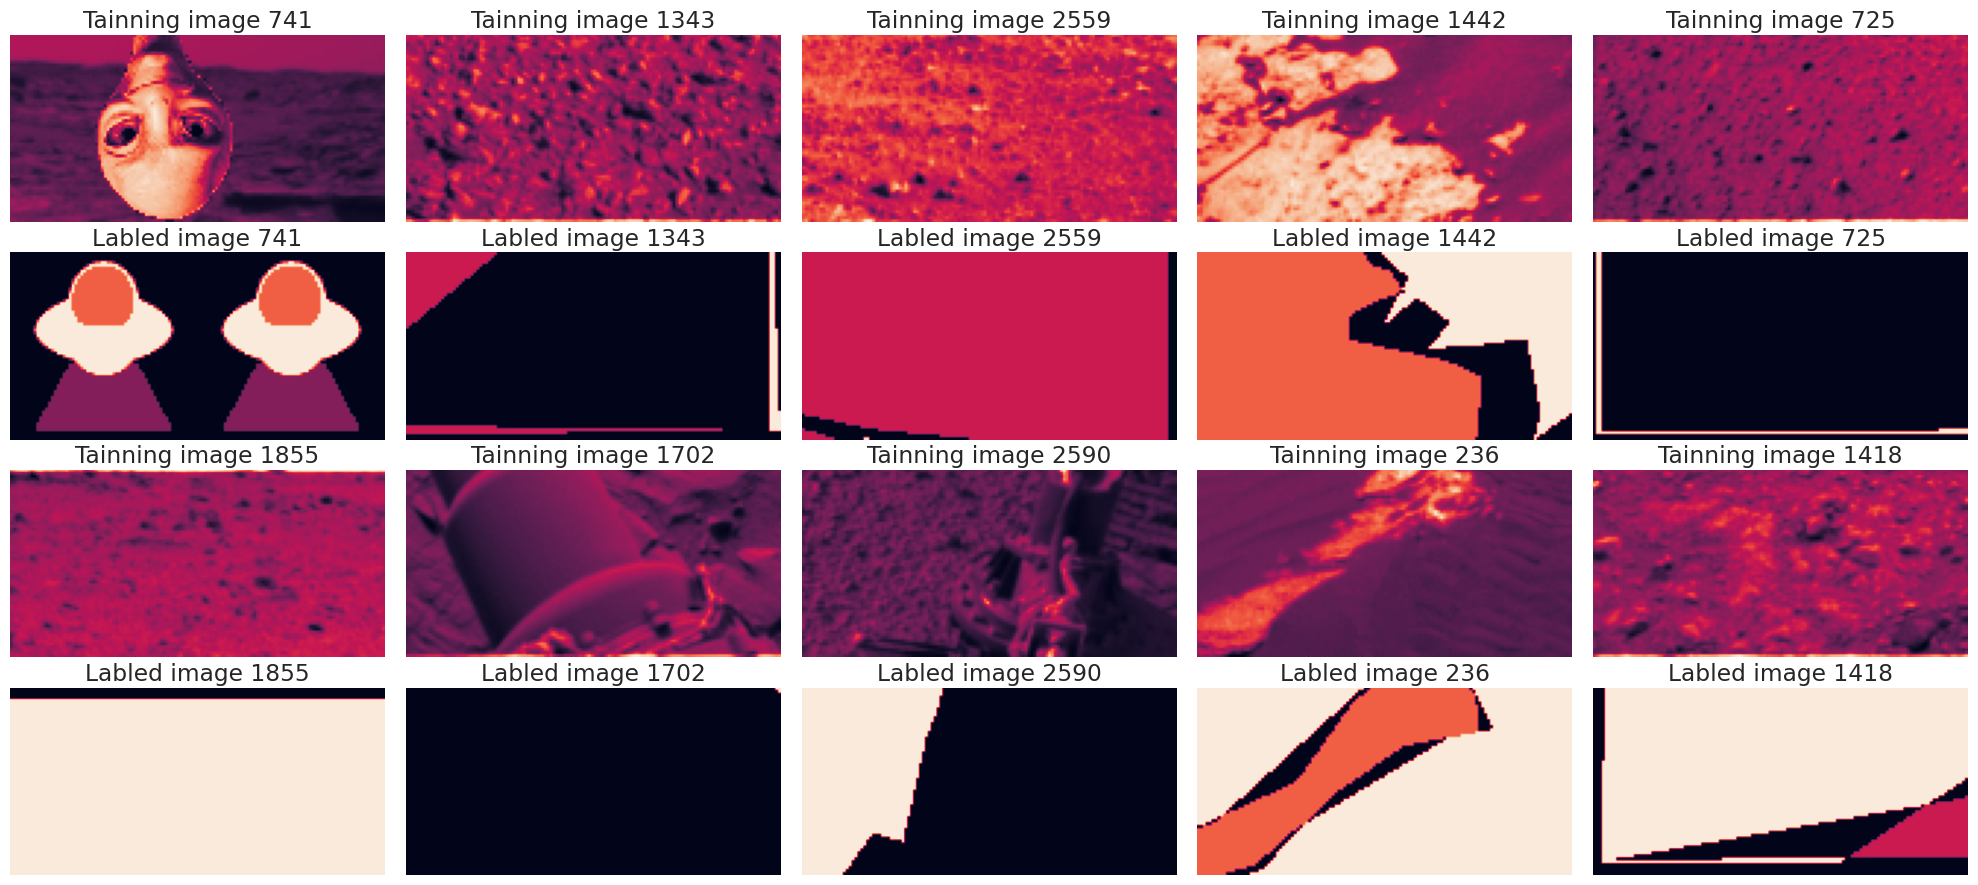

In [ ]:
dll.plotImages(X_train, y_train)

## 🛠️ Class Distribution Analysis

In [ ]:
# Add color channel and rescale pixels between 0 and 1
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

print(f"Input shape: {input_shape}")
print(f"Number of classes: {num_classes}")

Input shape: (64, 128, 1)
Number of classes: 5


In [ ]:
classCount, classesExamples = dll.calculateClassDistribution(y_train)
classTitles = ['Num. Imgs with 0', 'Num. Imgs with 1', 'Num. Imgs with 2', 'Num. Imgs with 3', 'Num. Imgs with 4']

In [ ]:
print(f'''
The amount of images with a label 0 is: {classCount[0]}
The amount of images with a label 1 is: {classCount[1]}
The amount of images with a label 2 is: {classCount[2]}
The amount of images with a label 3 is: {classCount[3]}
The amount of images with a label 4 is: {classCount[4]}
      ''')


The amount of images with a label 0 is: 2197
The amount of images with a label 1 is: 1391
The amount of images with a label 2 is: 1270
The amount of images with a label 3 is: 973
The amount of images with a label 4 is: 63
      


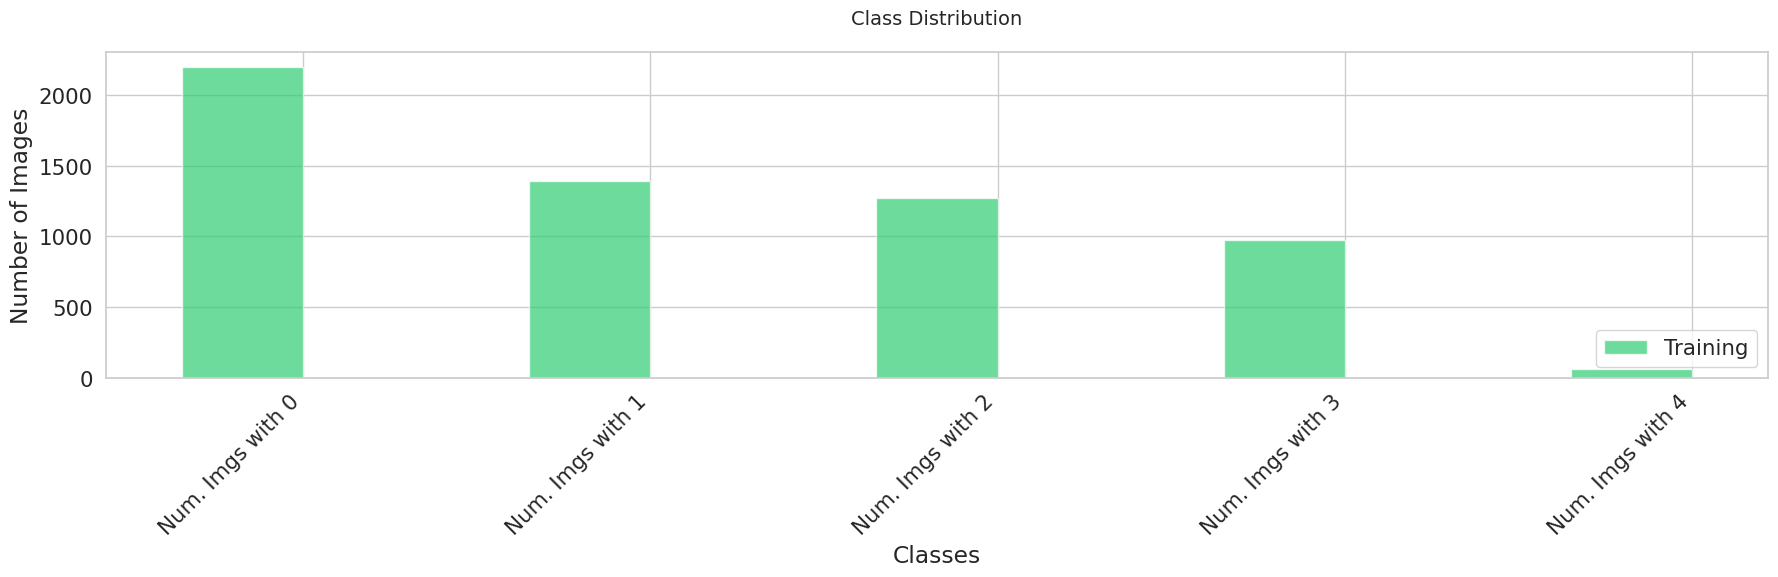

In [ ]:
dll.plotClassDistribution(classCount, classTitles)

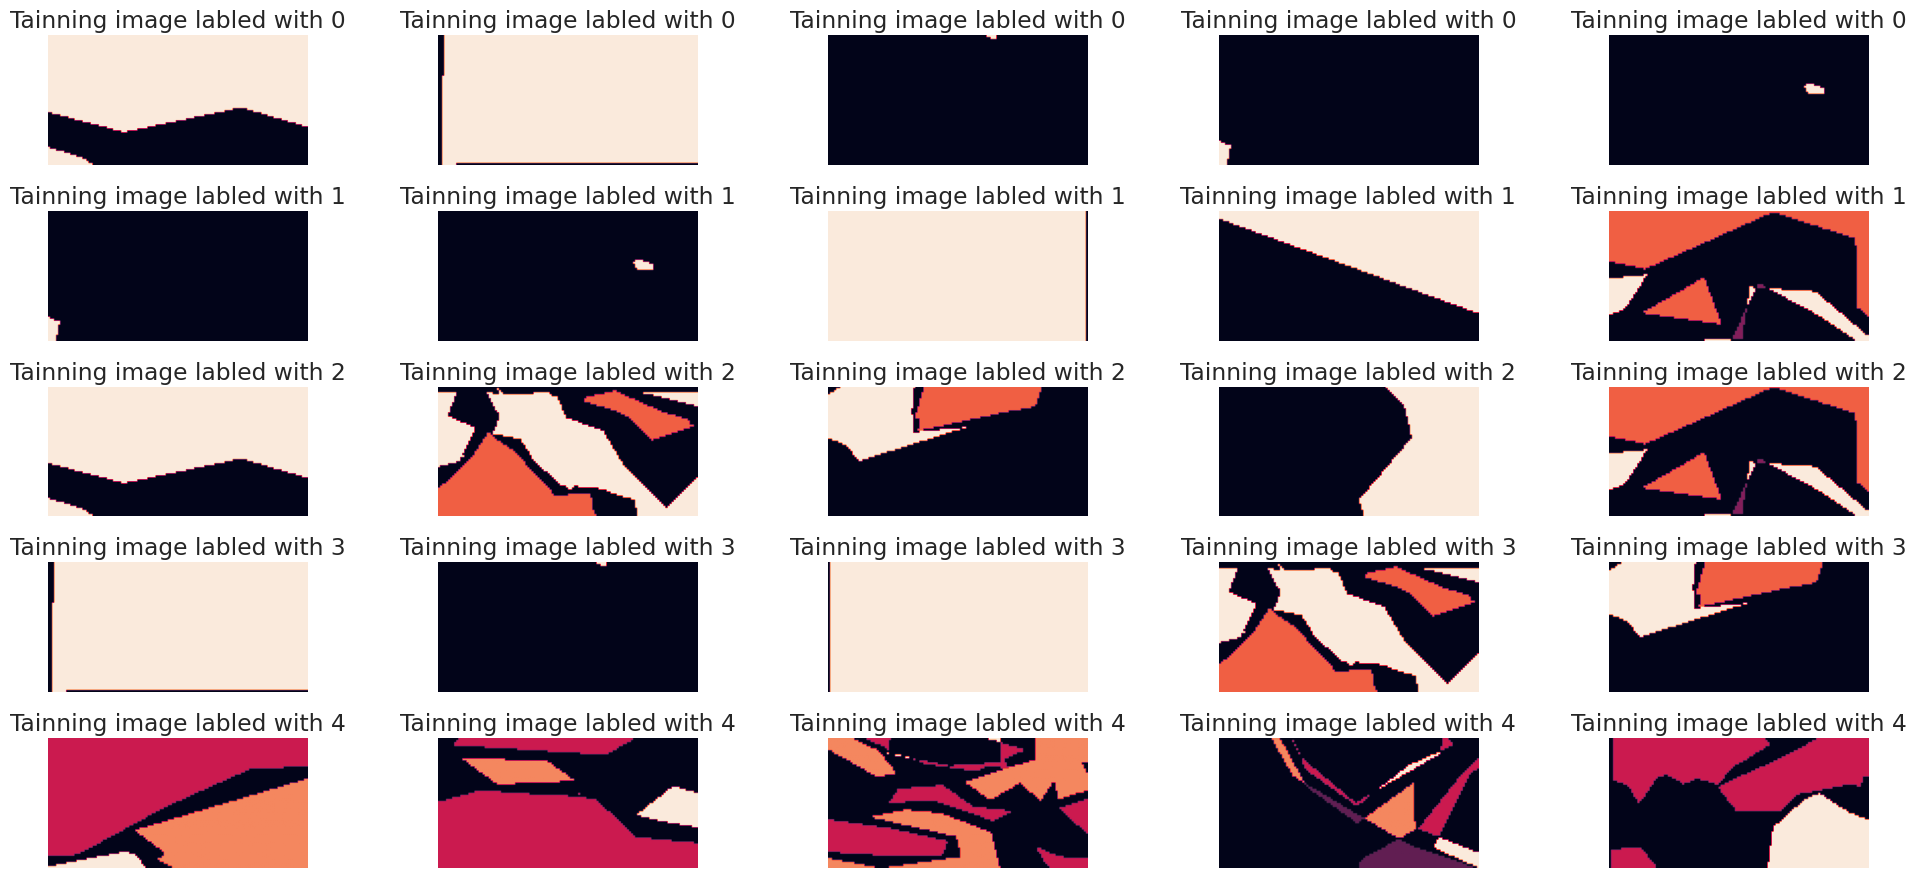

In [ ]:
dll.plotDifferentClassesExamples(y_train, classesExamples)

# Oversampling by pure Reusage

In [14]:
def countSamplesInDatasetCreation(dataset):
  '''
  Counts the number of samples in a dataset.
  Aims to verify if, due to a big difference in the amount of smaples for some classes,
  there will be a significant inbalace in dataet creation.
  '''
  num_0 = 0
  num_1 = 0
  num_2 = 0
  num_3 = 0
  num_4 = 0

  for i in range(len(dataset)):
    for j in np.unique(dataset[i]):
      match j:
          case 0.0:
              num_0 += 1
          case 1.0:
              num_1 += 1
          case 2.0:
              num_2 += 1
          case 3.0:
              num_3 += 1
          case 4.0:
              num_4 += 1

  return np.array([num_0, num_1, num_2, num_3, num_4])

In [21]:
train_img, val_img, train_lbl, val_lbl = train_test_split(
    X_train, y_train, test_size=300, random_state=42
)
print("Data splitted!")

print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

Data splitted!

Number of images:
Train: 2315
Validation: 300


In [ ]:
def make_dataset(X, y, batch_size=64, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    # Create dataset from file paths
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create the datasets
train_dataset = make_dataset(
    train_img, train_lbl,
    batch_size=64,
    seed=42
)

val_dataset = make_dataset(
    val_img, val_lbl,
    batch_size=64,
)

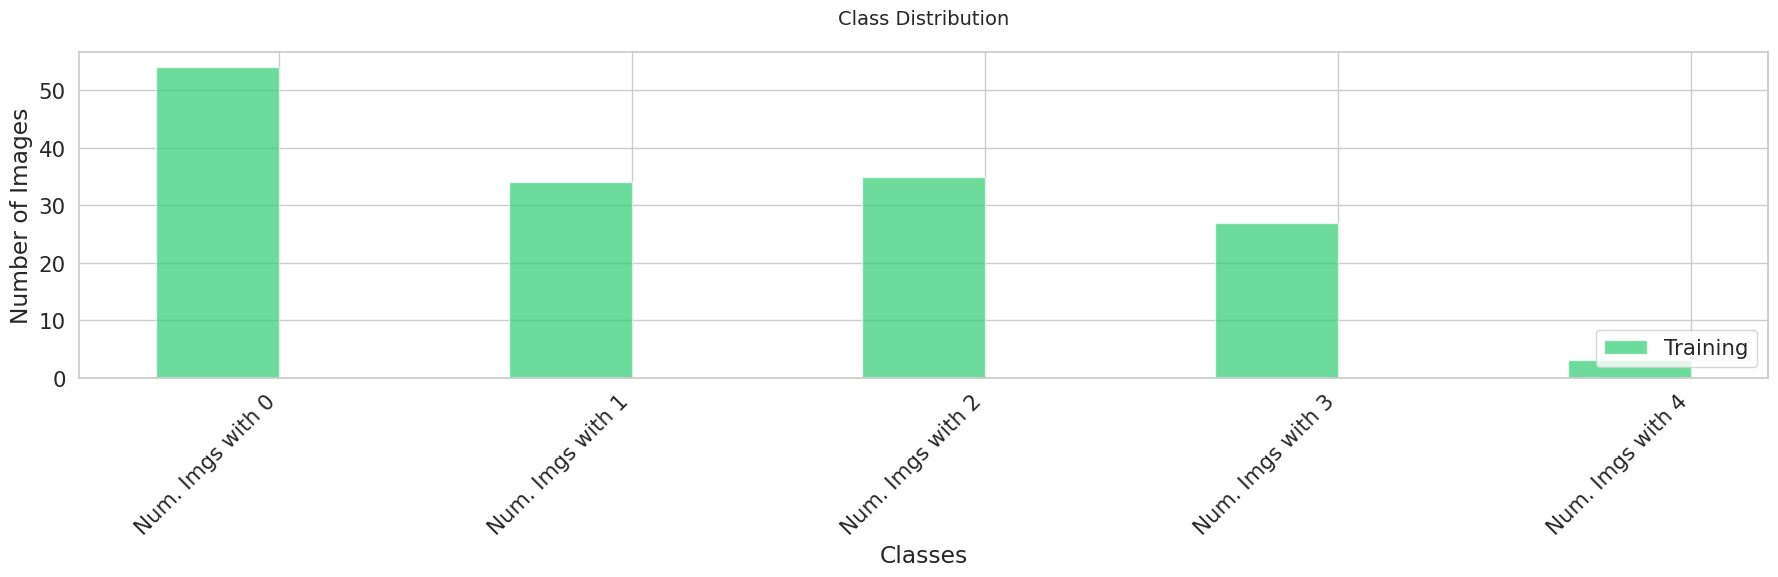

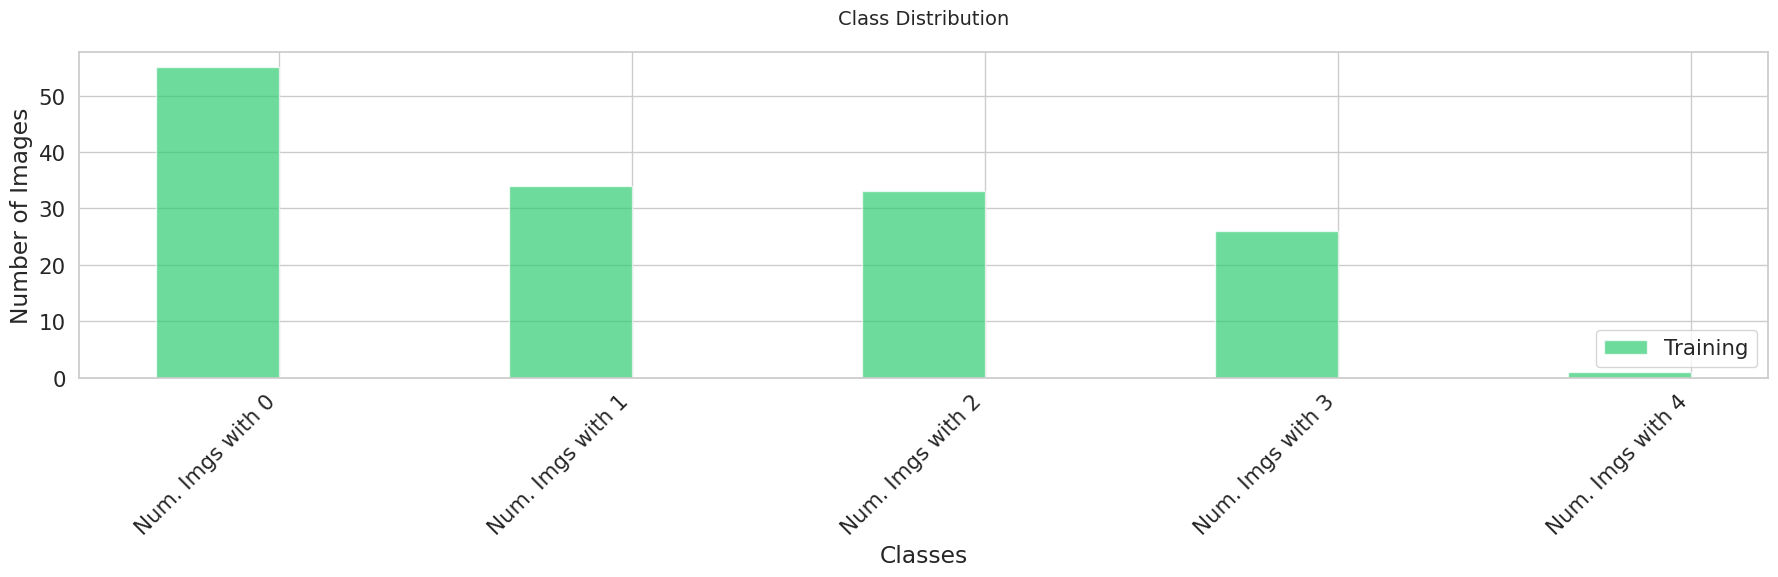

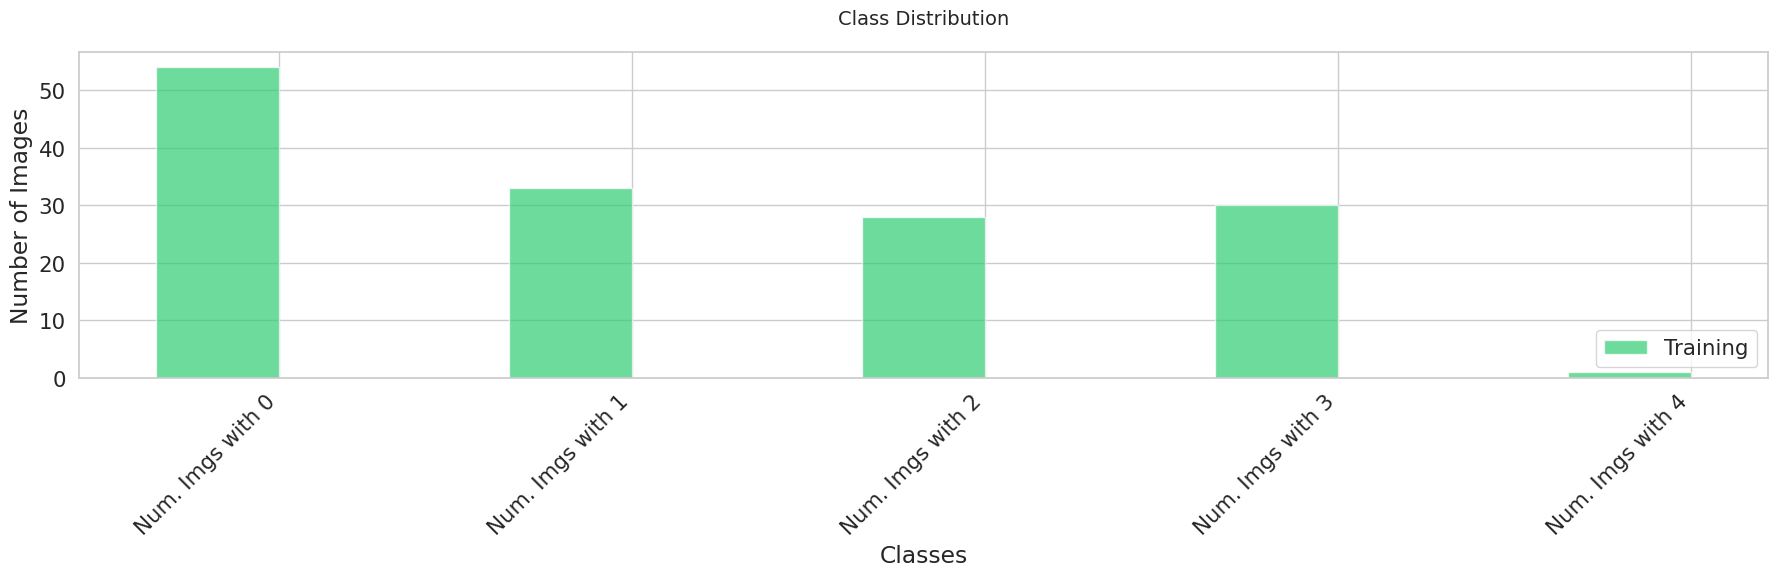

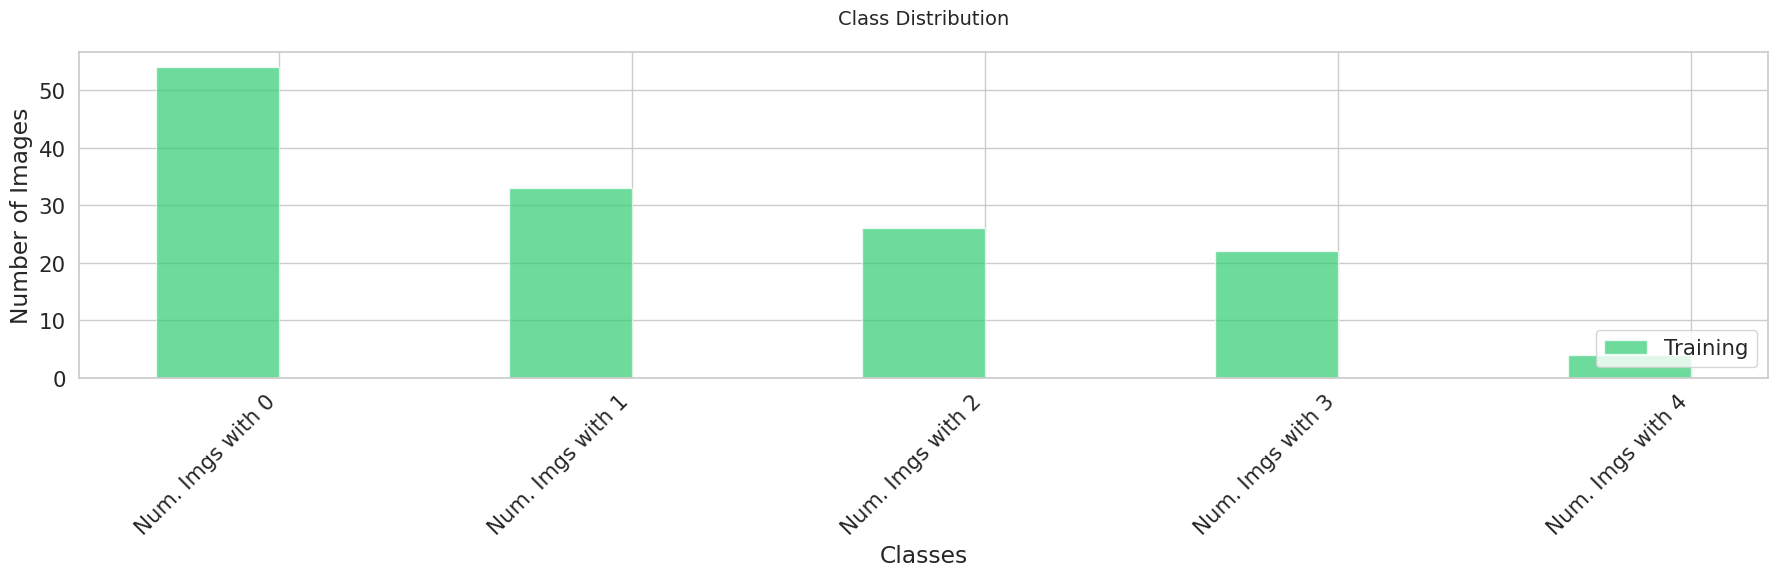

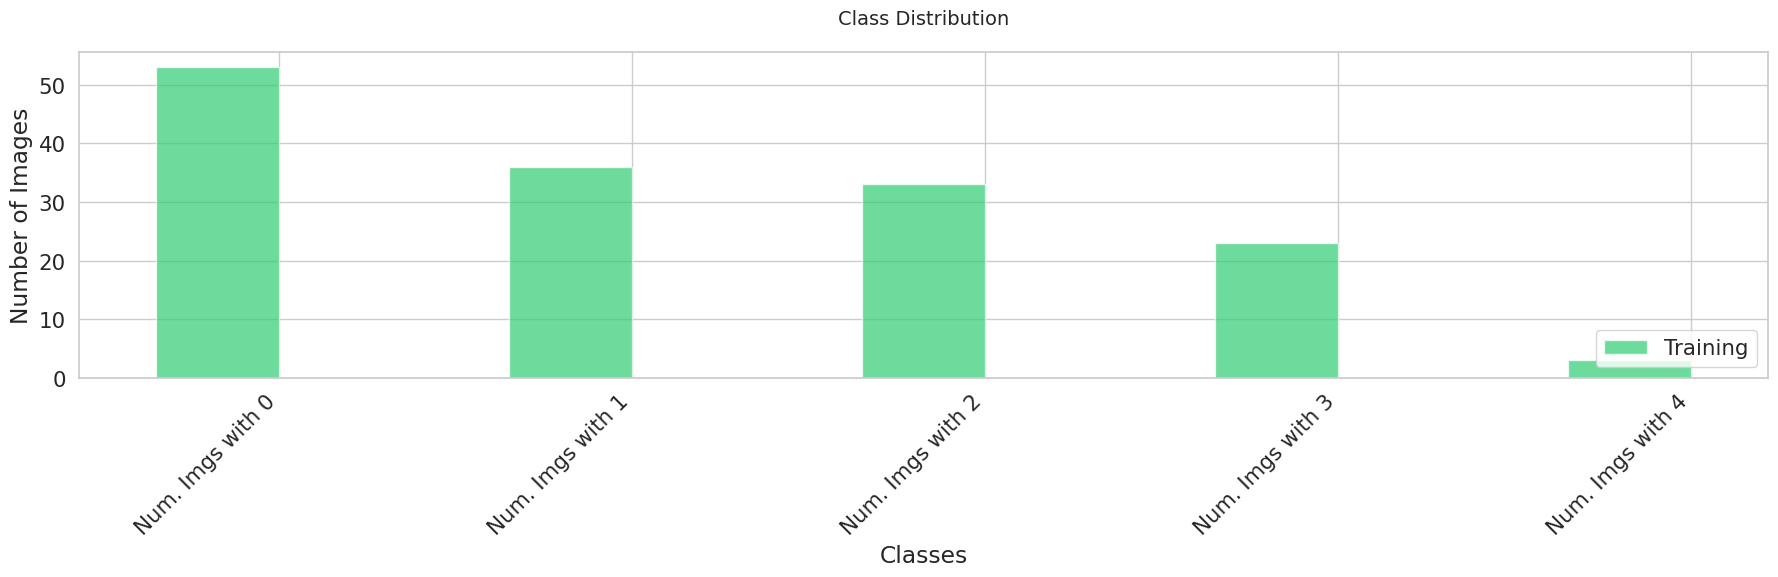

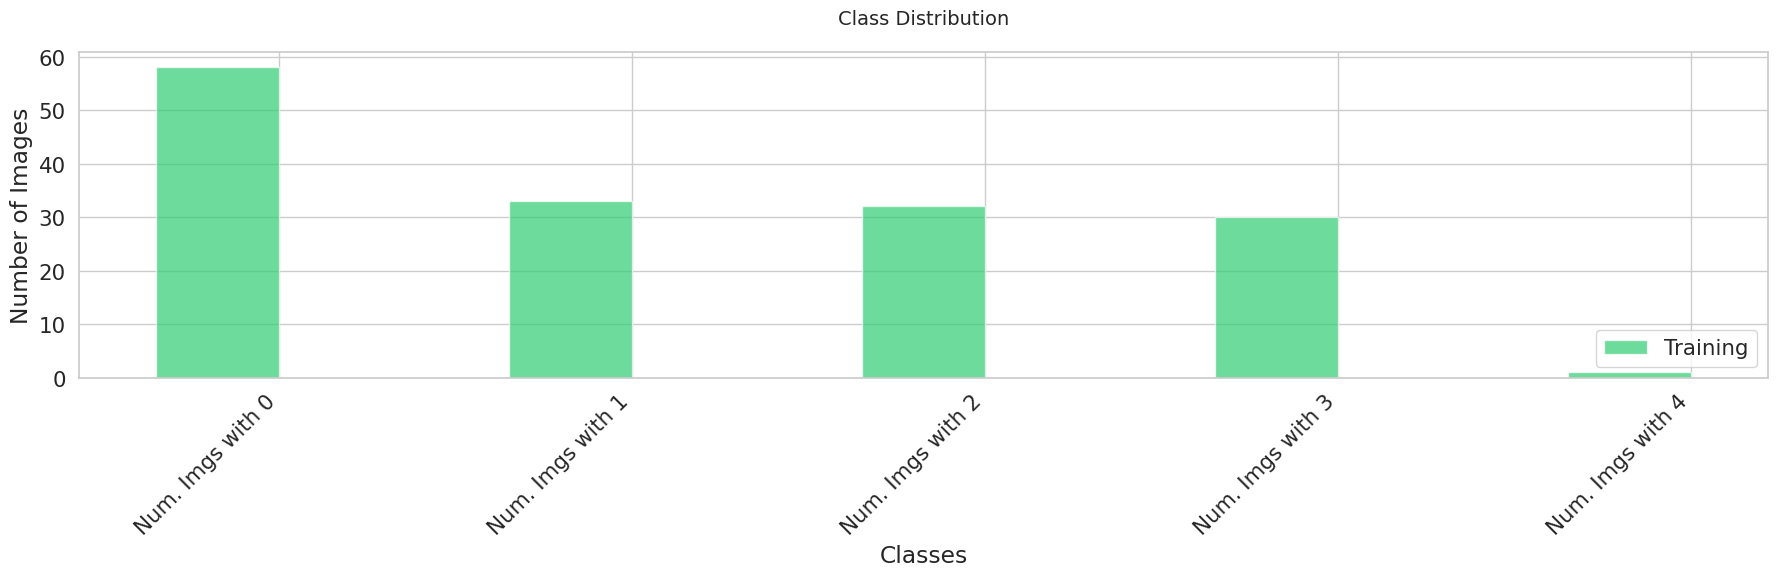

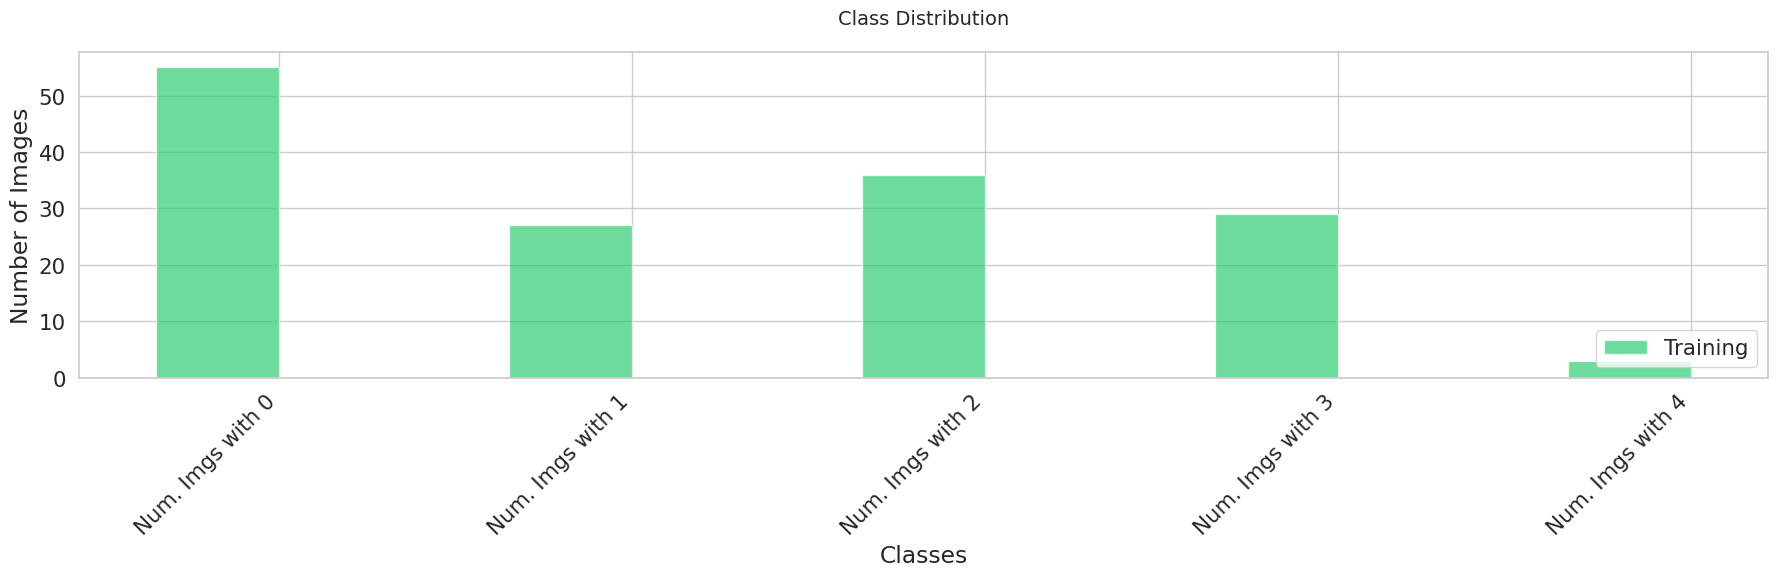

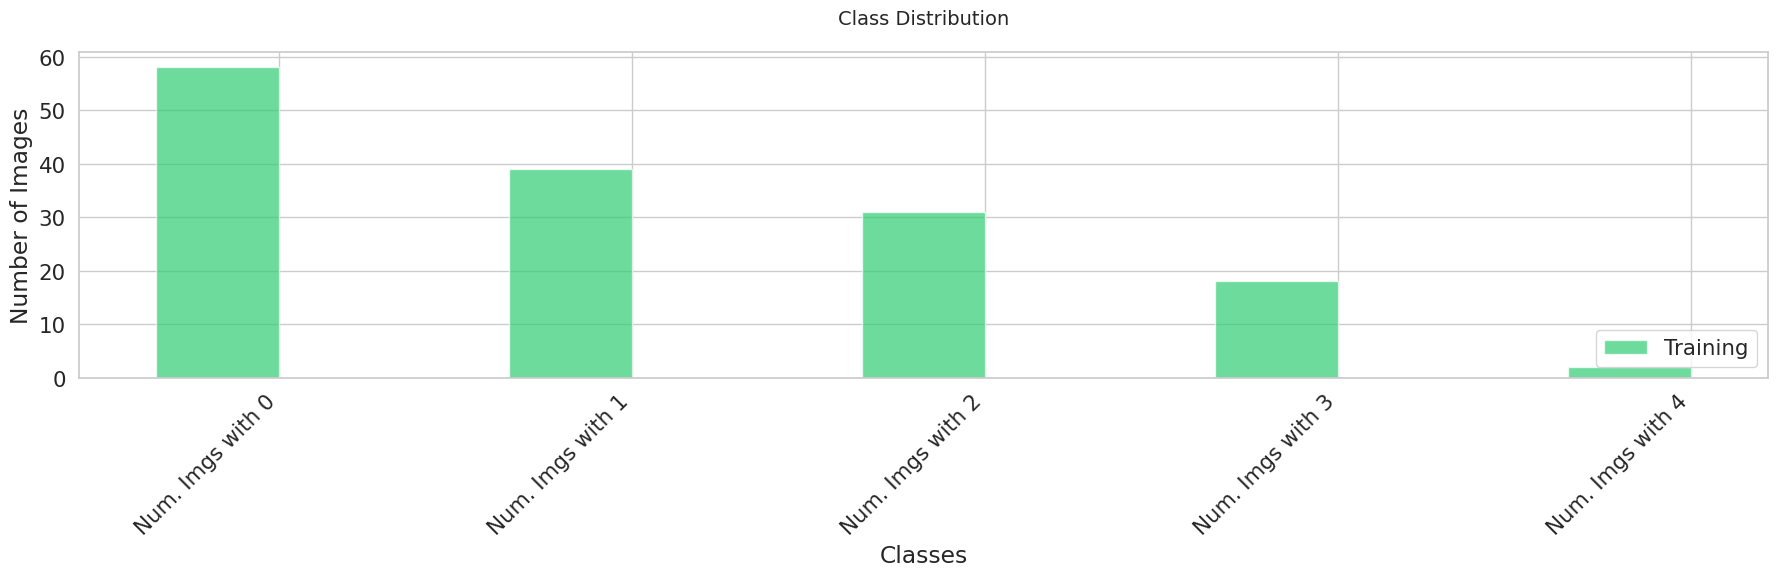

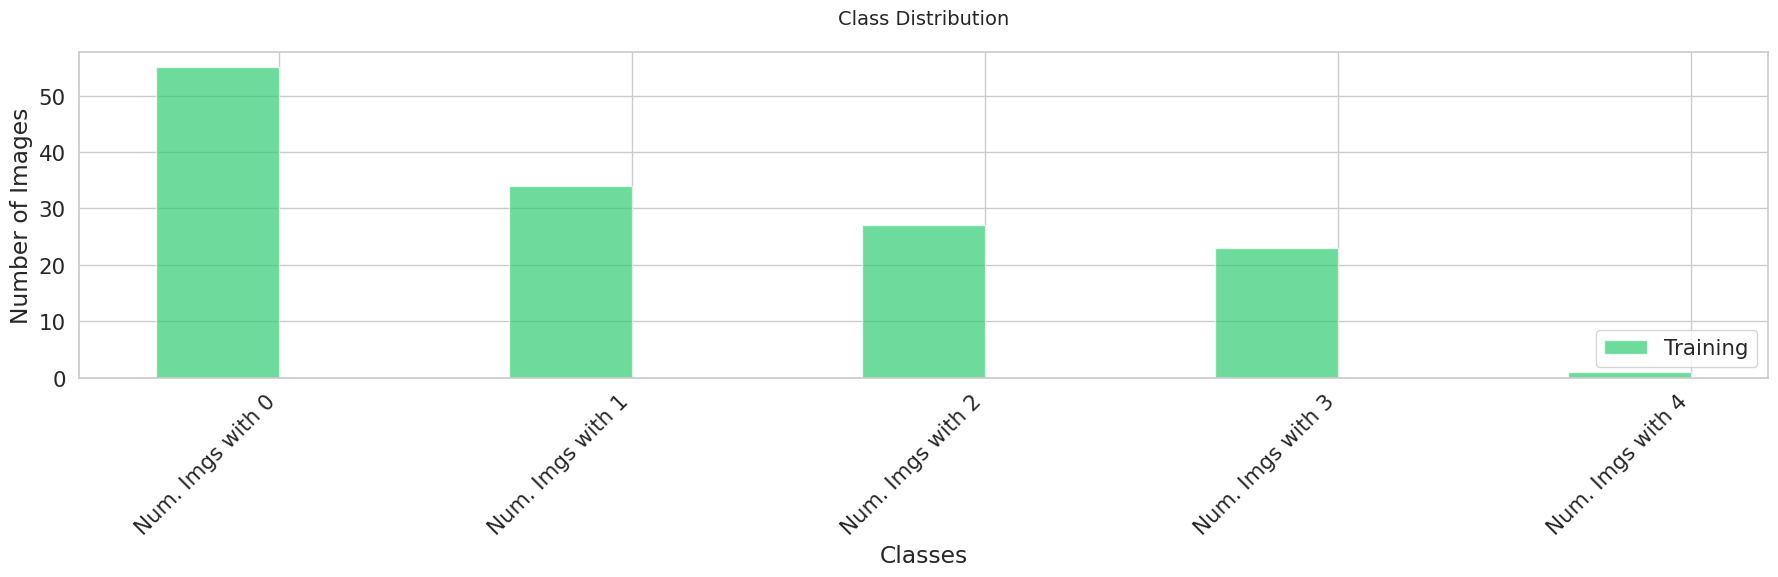

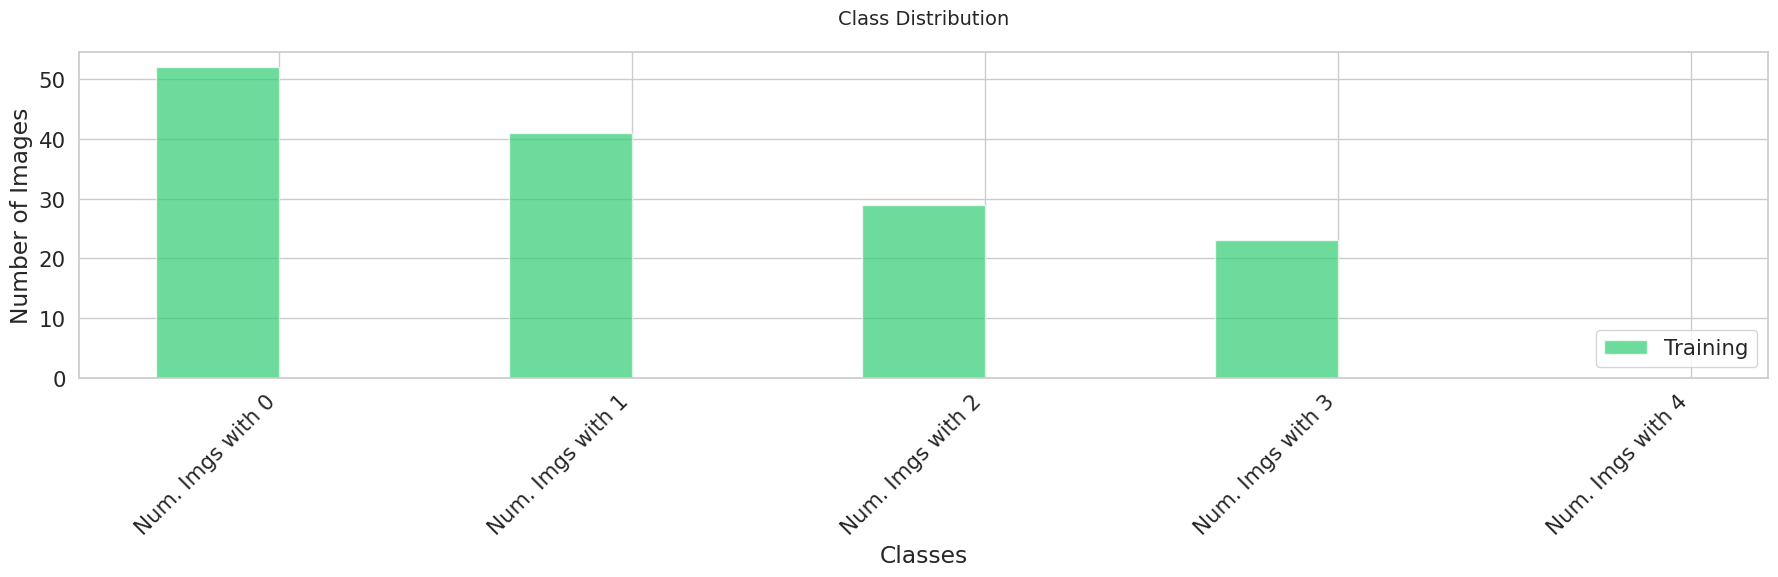

In [ ]:
count = 0
for i in train_dataset:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)
  count += 1
  if count == 10:
    break

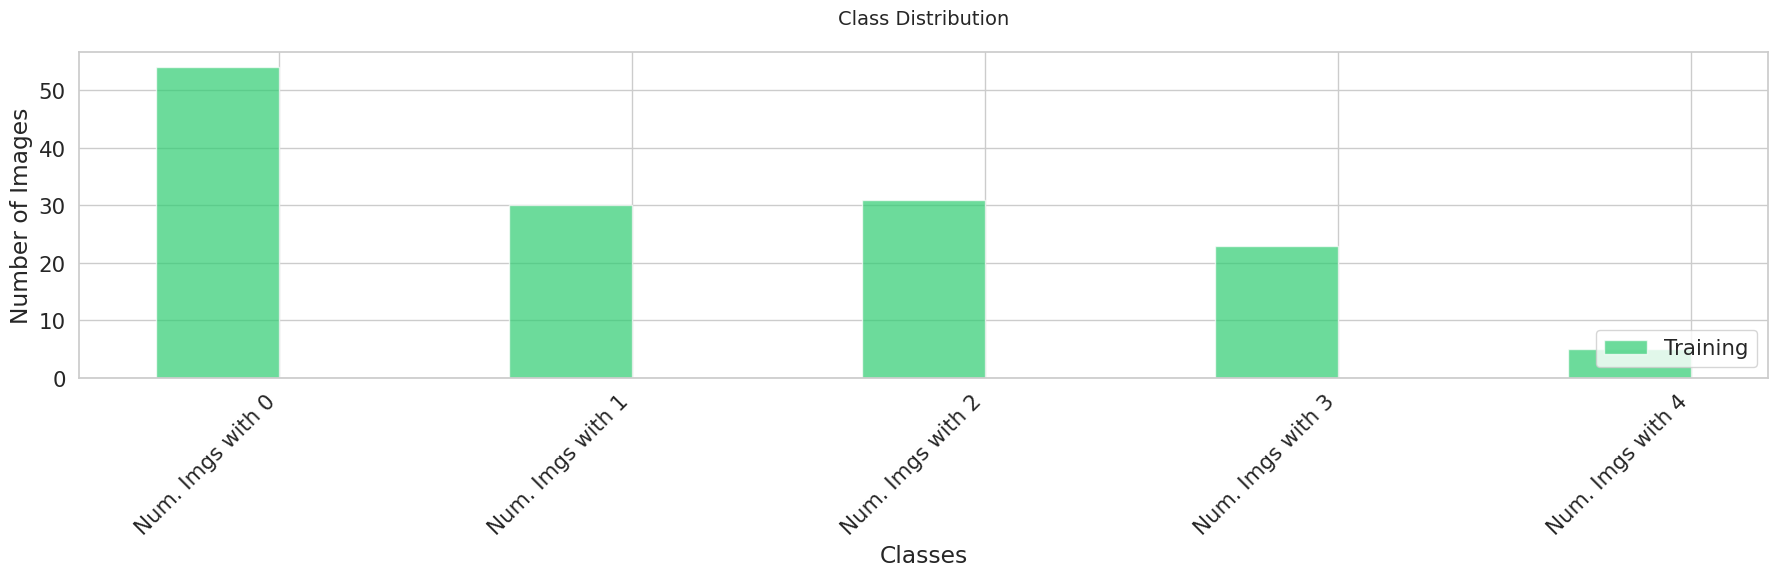

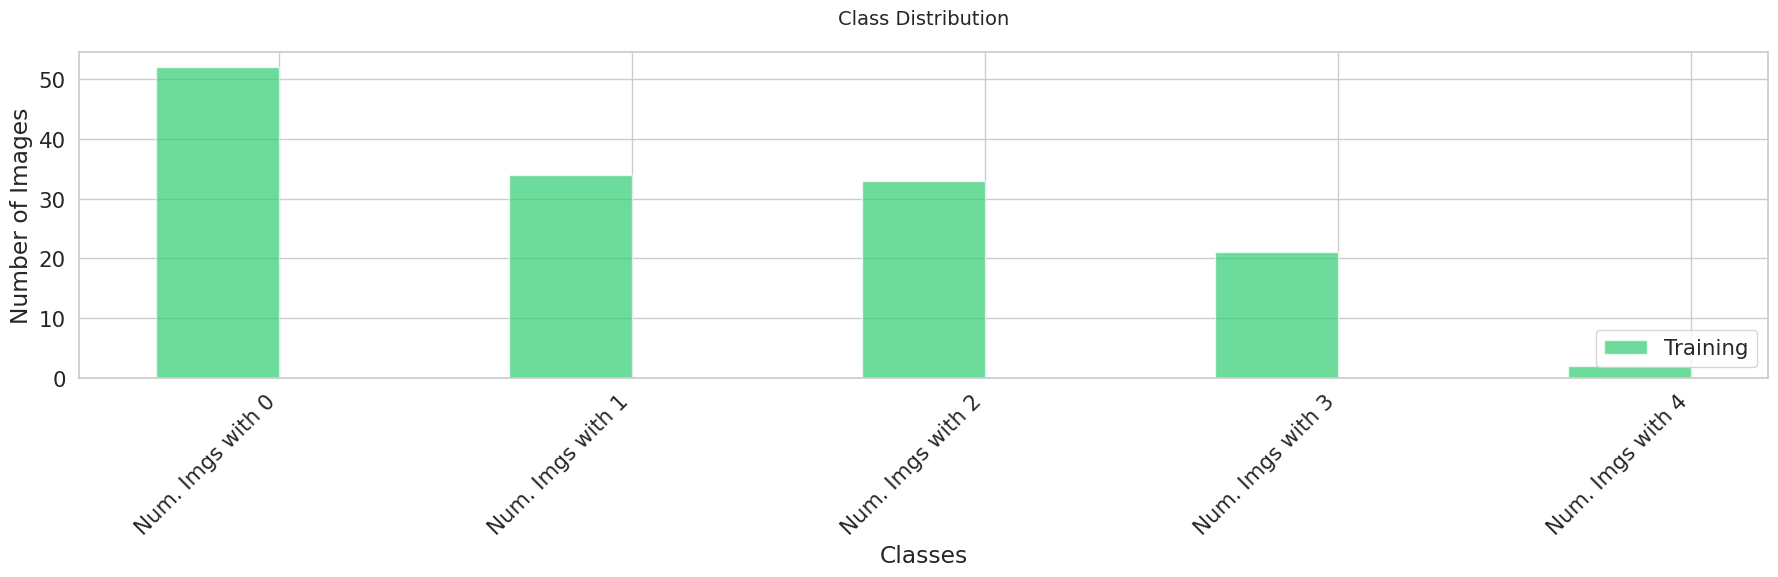

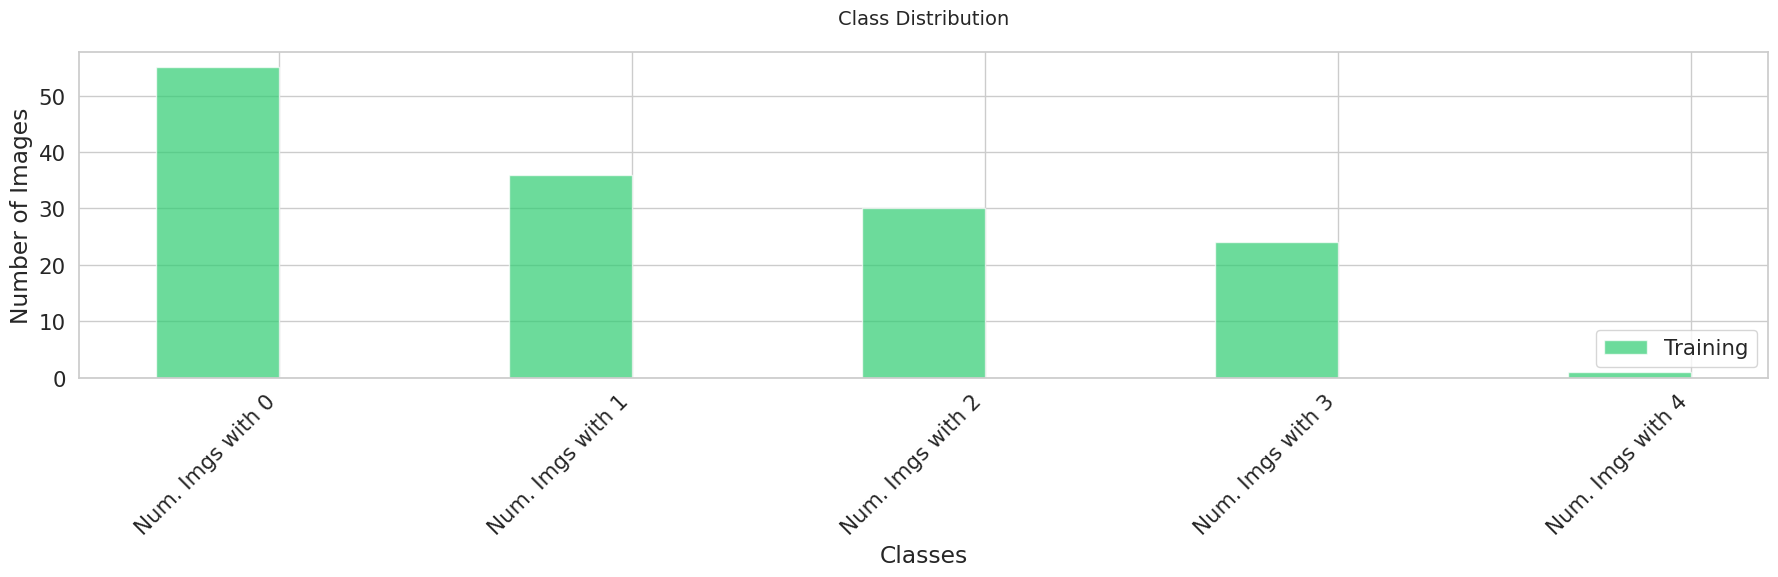

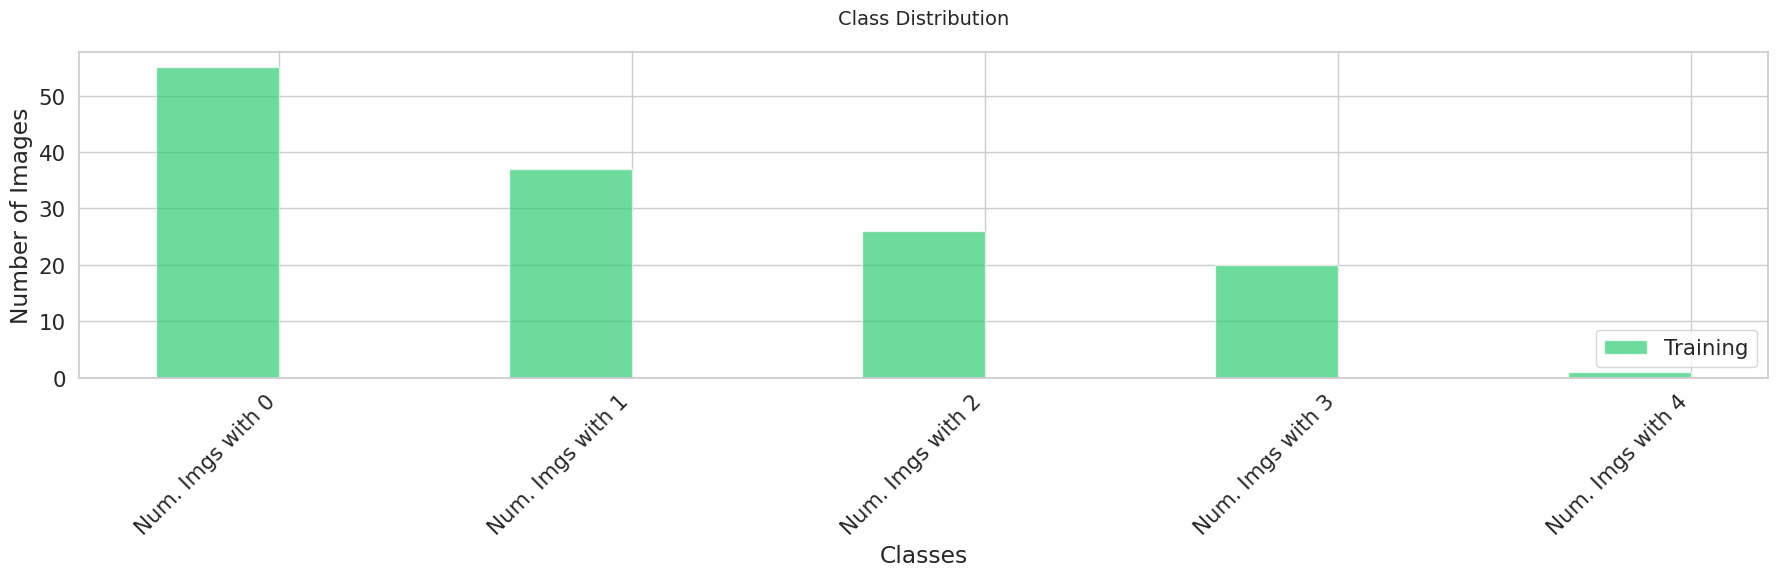

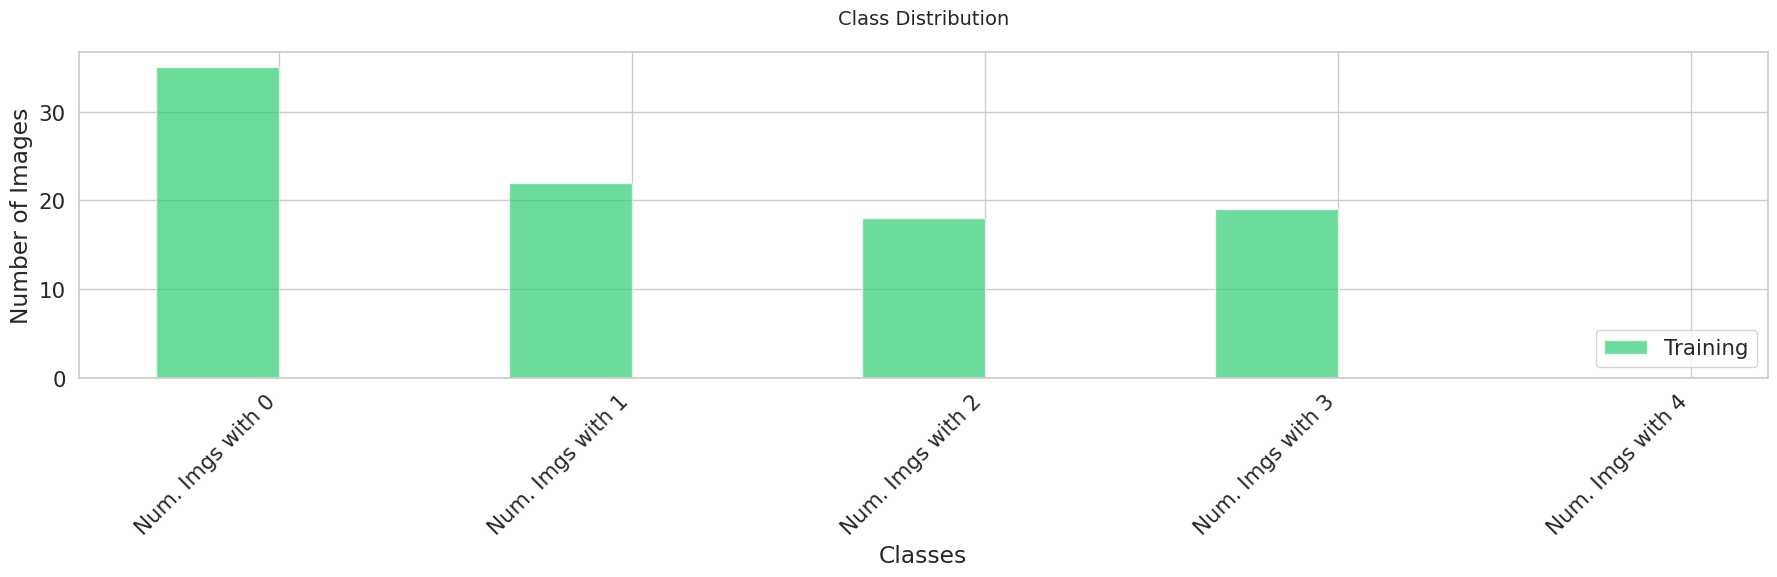

In [ ]:
count = 0
for i in val_dataset:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)
  count += 1
  if count == 10:
    break

In [ ]:
def make_dataset_balanced(X, y, batch_size=64, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    dataset_with4 = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.equal(y, 4)))
    dataset_with41 = dataset_with4
    dataset_with42 = dataset_with4
    dataset_with43 = dataset_with4
    dataset_with44 = dataset_with4
    dataset_with45 = dataset_with4
    dataset_with46 = dataset_with4
    dataset_with47 = dataset_with4
    dataset_with48 = dataset_with4
    dataset_with49 = dataset_with4
    dataset_with50 = dataset_with4
    dataset_with51 = dataset_with4
    dataset_with52 = dataset_with4
    dataset_with53 = dataset_with4
    dataset_with54 = dataset_with4
    dataset_with55 = dataset_with4
    dataset_with56 = dataset_with4
    dataset_with57 = dataset_with4
    dataset_with58 = dataset_with4
    dataset_with59 = dataset_with4
    dataset_with60 = dataset_with4
    dataset_with61 = dataset_with4
    dataset_with62 = dataset_with4
    dataset_with63 = dataset_with4
    dataset_with64 = dataset_with4
    dataset_rest = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.not_equal(y, 4)))
    dataset = tf.data.Dataset.sample_from_datasets(
        [dataset_with4, dataset_with41, dataset_with42, dataset_with43, dataset_with44,
         dataset_with45, dataset_with46, dataset_with47, dataset_with48, dataset_with49,
         dataset_with50, dataset_with51, dataset_with52, dataset_with53, dataset_with54,
         dataset_with55, dataset_with56, dataset_with57, dataset_with58, dataset_with59,
         dataset_with60, dataset_with61, dataset_with62, dataset_with63, dataset_with64,
         dataset_rest],
        # weights=[0.02, 0.02, .02, .02, .02,
        #          0.02, 0.02, .02, .02, .02,
        #          0.02, 0.02, .02, .02, .02,
        #          0.02, 0.02, .02, .02, .02,
        #          0.02, 0.02, .02, .02, .02,
        #          .5])
          weights=[0.016, 0.016, .016, .016, .016,
                    0.016, 0.016, .016, .016, .016,
                    0.016, 0.016, .016, .016, .016,
                    0.016, 0.016, .016, .016, .016,
                    0.016, 0.016, .016, .016, .016,
                    .5])


    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Create the datasets
train_dataset_balanced = make_dataset_balanced(
    train_img, train_lbl,
    batch_size=32,
    seed=42
)

val_dataset_balanced = make_dataset_balanced(
    val_img, val_lbl,
    batch_size=64,
)

In [ ]:
count = 0
for i in train_dataset_balanced:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)

Output hidden; open in https://colab.research.google.com to view.

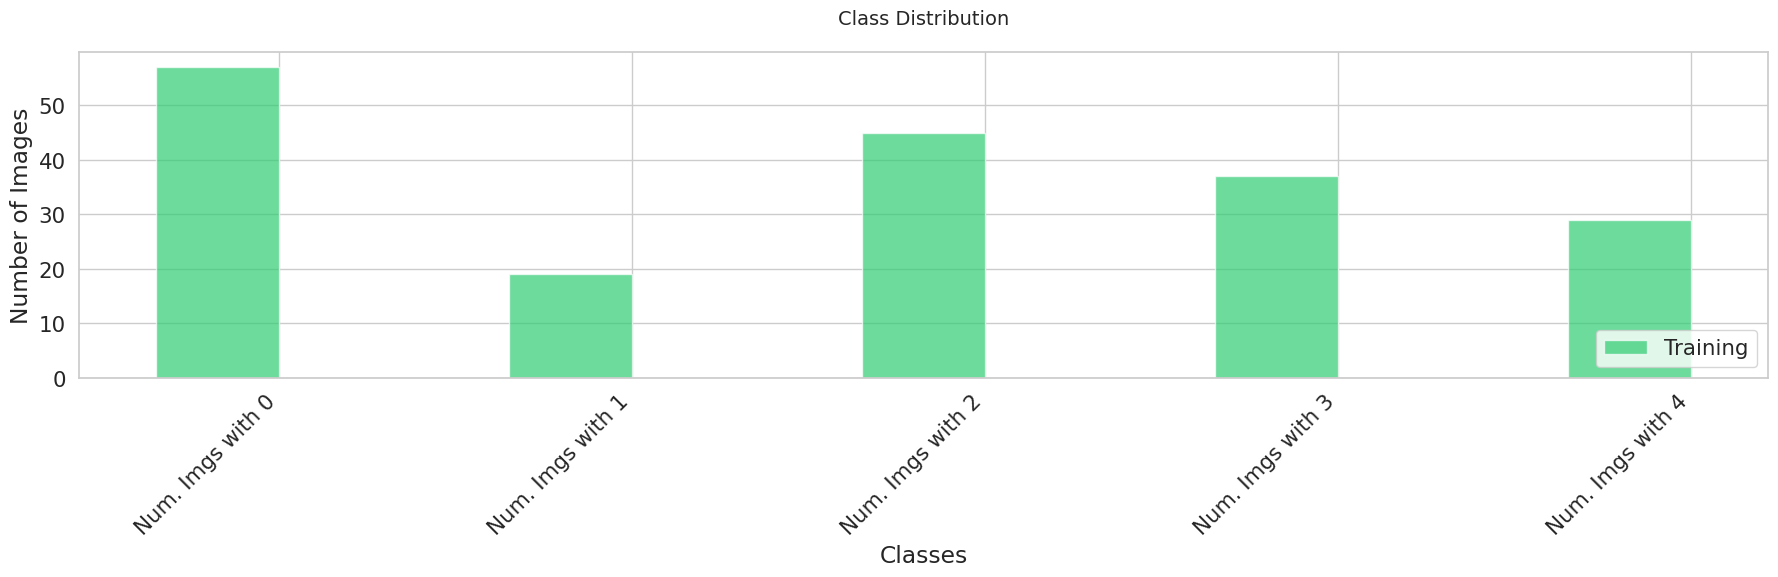

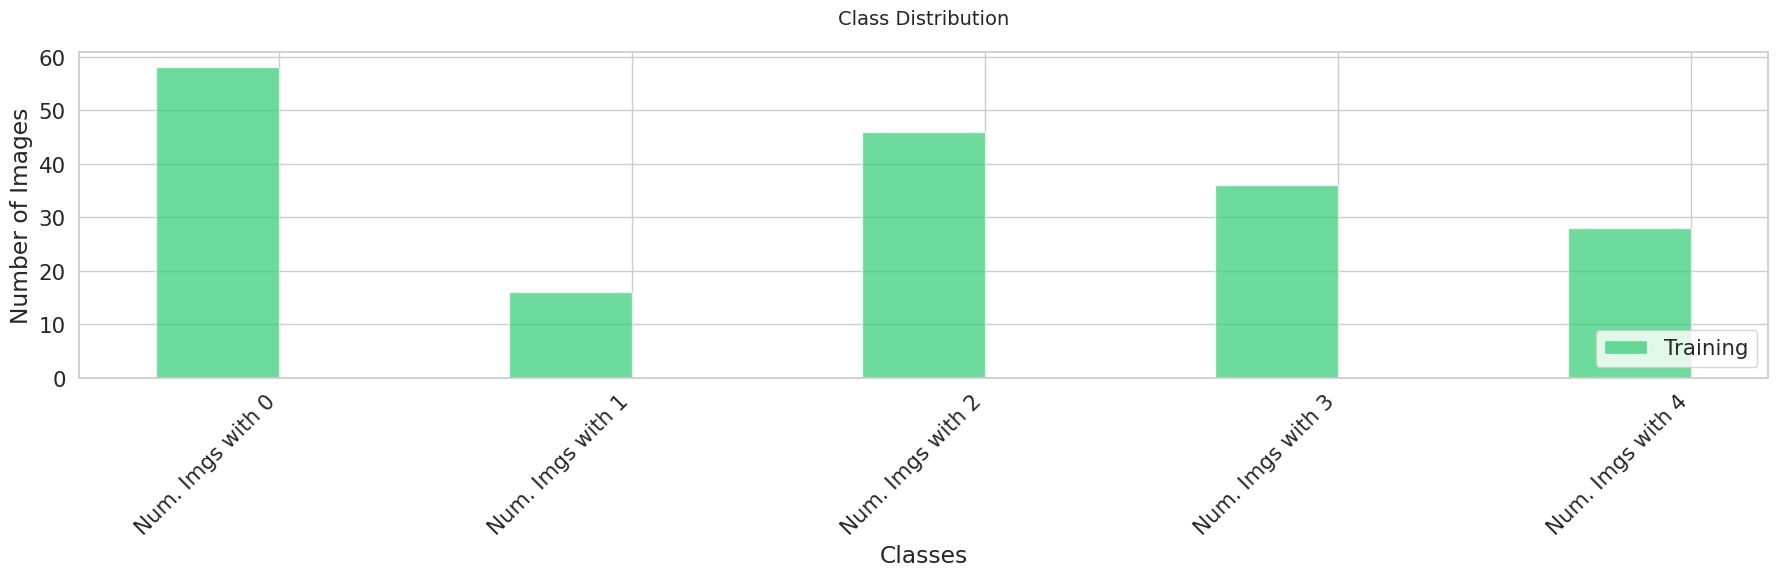

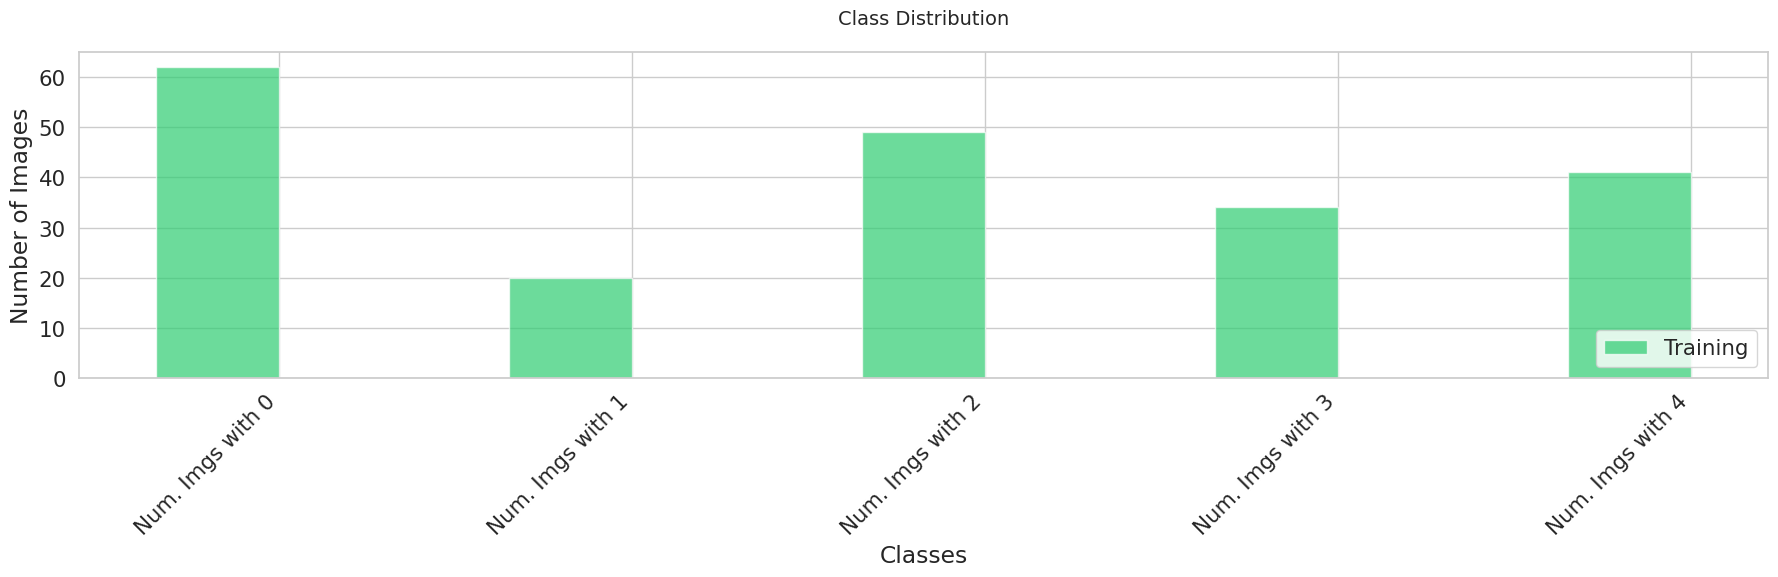

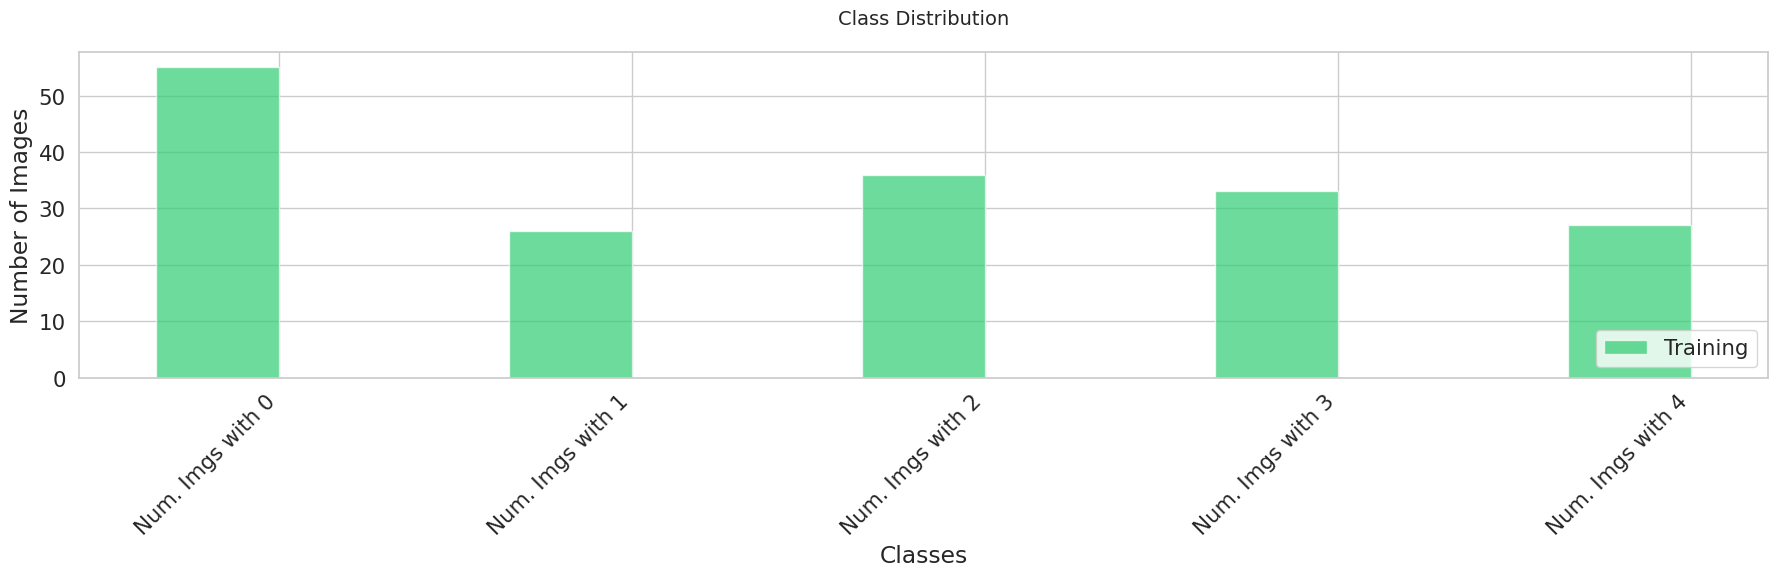

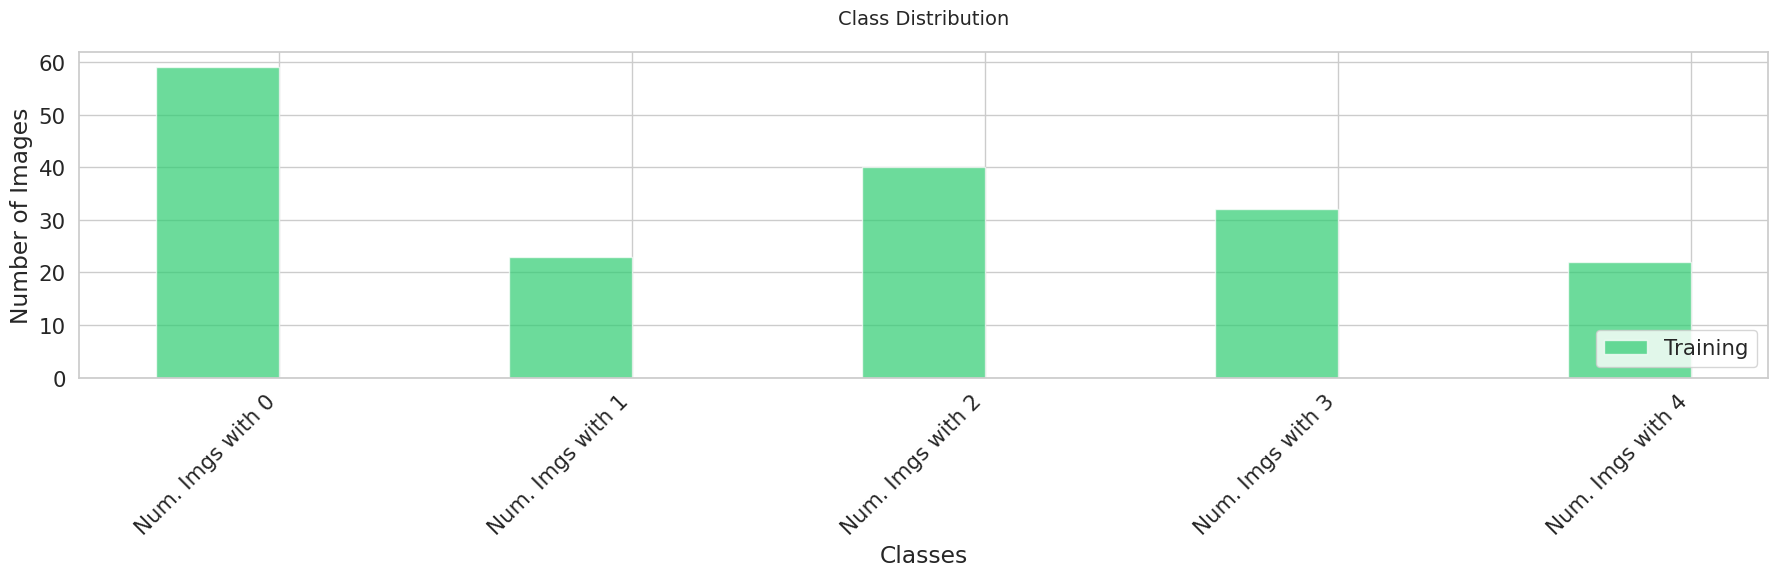

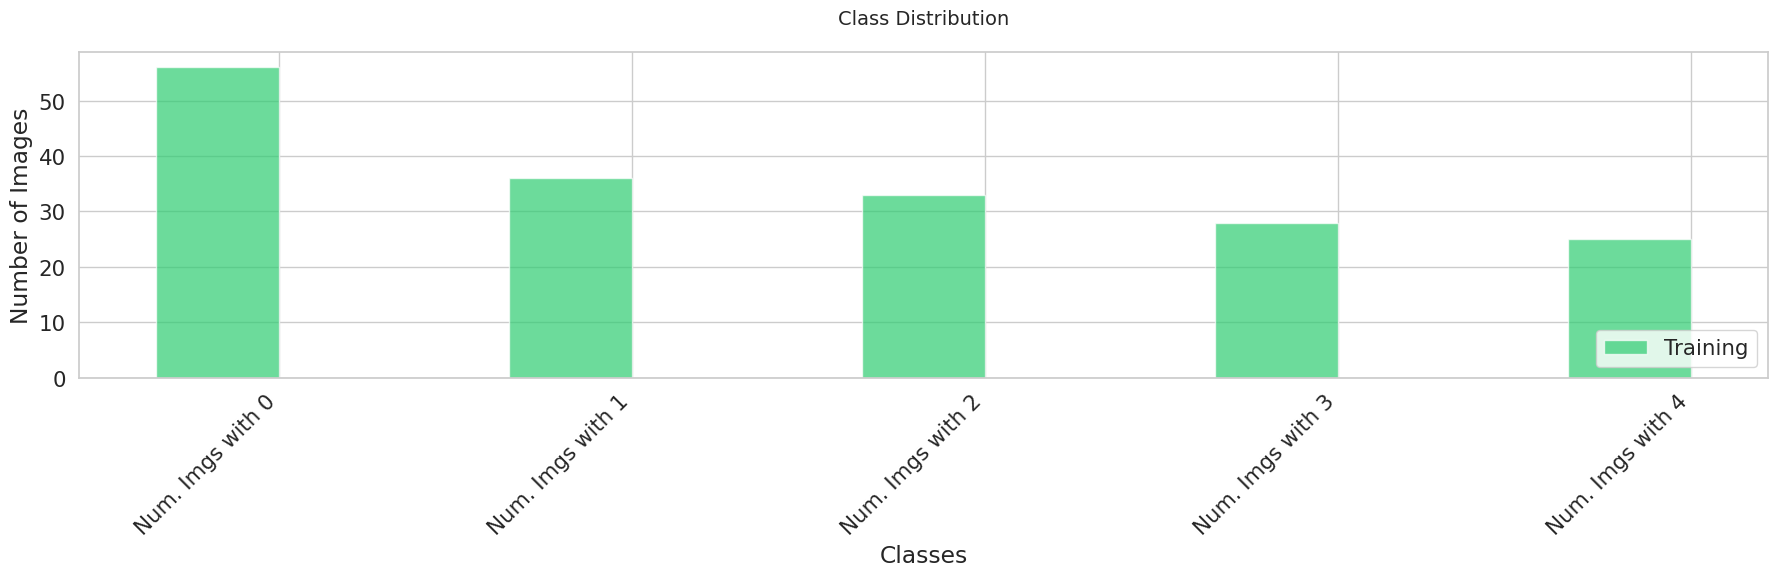

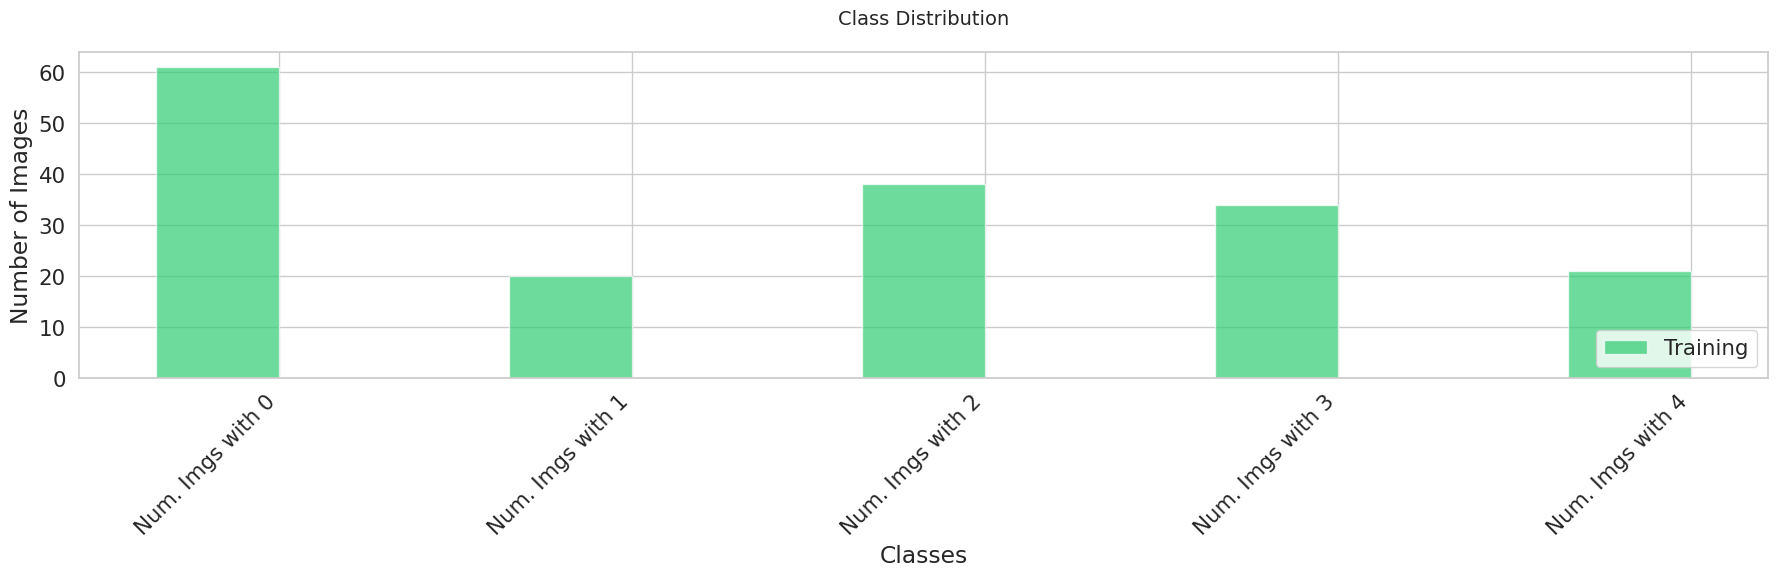

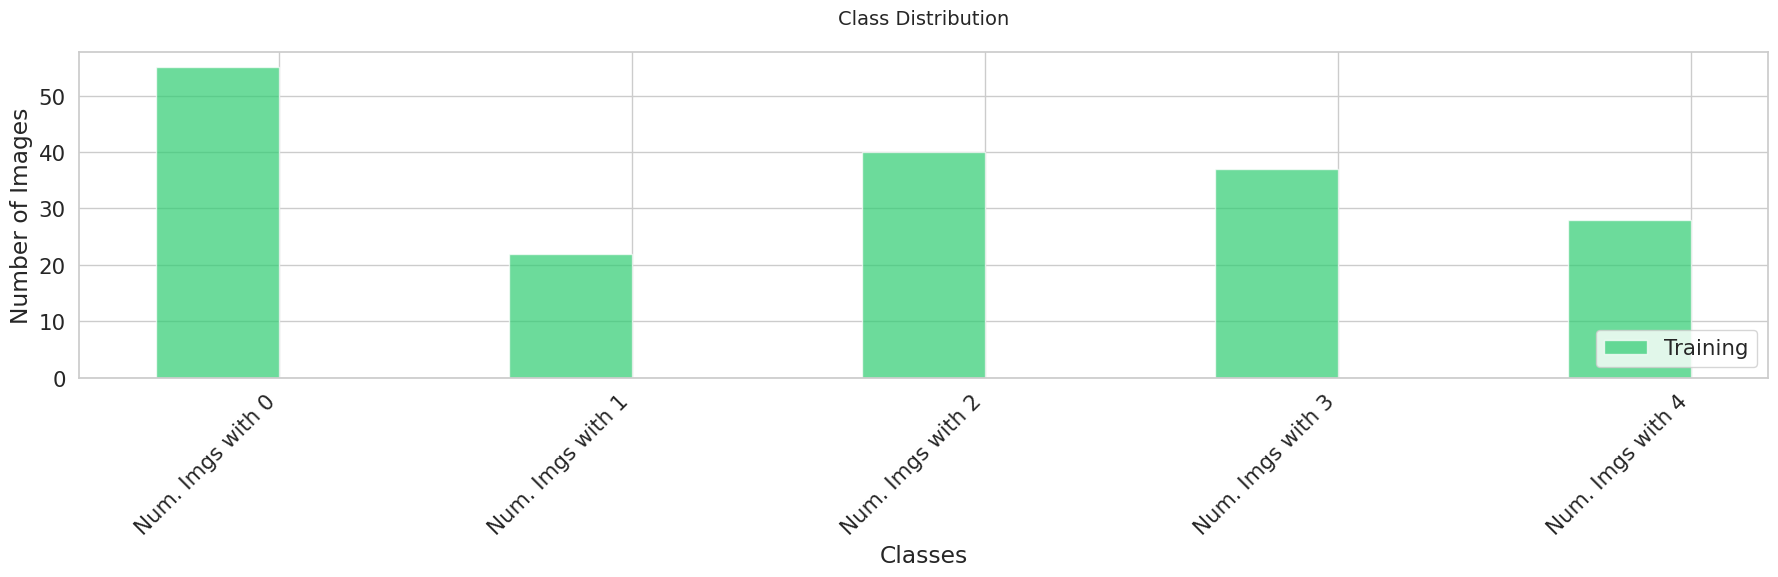

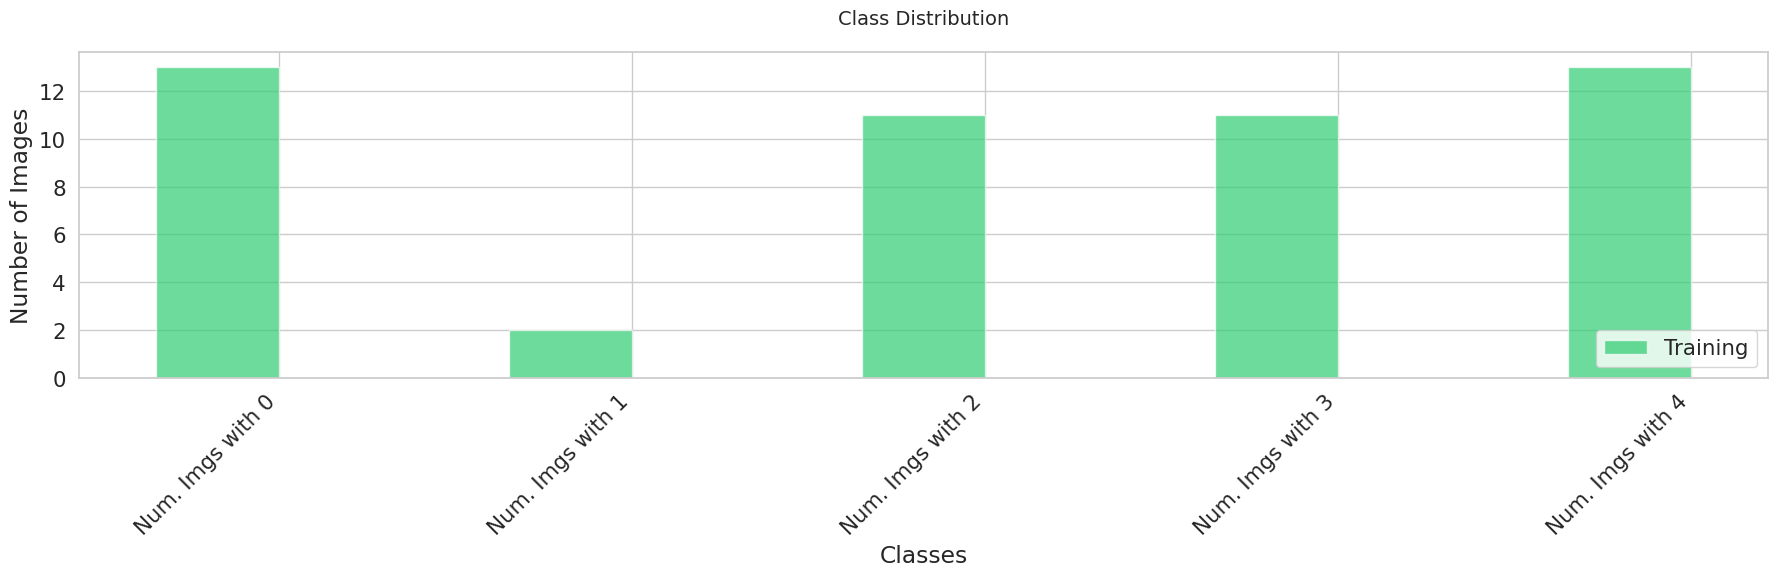

In [ ]:
count = 0
for i in val_dataset_balanced:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)
  count += 1
  if count == 10:
    break

# Oversampling by image generation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(rotation_range=10, width_shift_range=[0,1], height_shift_range=[0,1], horizontal_flip=True, vertical_flip=True)

In [ ]:
num_4_examples = []

for i in range(len(y_train)):
    for j in np.unique(y_train[i]):
        match j:
            case 4.0:
              num_4_examples.append(i)

In [ ]:
len(num_4_examples)

63

In [ ]:
y_train = y_train[..., np.newaxis]

In [ ]:
seed = 0
for i in range(940):

  X_train = np.concatenate([X_train, np.array([datagen.random_transform(X_train[num_4_examples[i % 63]], seed=seed)])], axis=0)
  y_train = np.concatenate([y_train, np.array([datagen.random_transform(y_train[num_4_examples[i % 63]], seed=seed)])], axis=0)

In [ ]:
classCount, classesExamples = dll.calculateClassDistribution(y_train)
classTitles = ['Num. Imgs with 0', 'Num. Imgs with 1', 'Num. Imgs with 2', 'Num. Imgs with 3', 'Num. Imgs with 4']

In [ ]:
print(f'''
The amount of images with a label 0 is: {classCount[0]}
The amount of images with a label 1 is: {classCount[1]}
The amount of images with a label 2 is: {classCount[2]}
The amount of images with a label 3 is: {classCount[3]}
The amount of images with a label 4 is: {classCount[4]}
      ''')


The amount of images with a label 0 is: 3137
The amount of images with a label 1 is: 1748
The amount of images with a label 2 is: 1941
The amount of images with a label 3 is: 1661
The amount of images with a label 4 is: 928
      


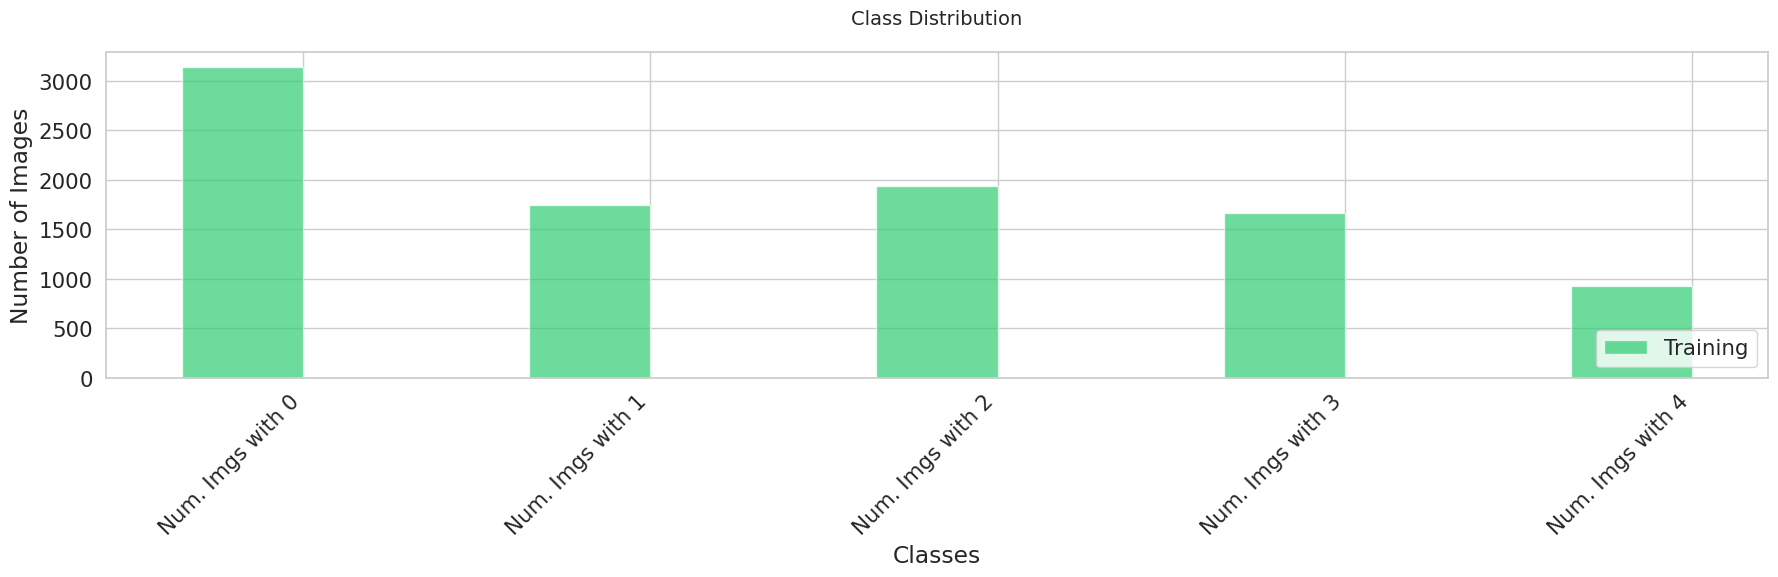

In [ ]:
dll.plotClassDistribution(classCount, classTitles)

In [ ]:
file_name = 'oversampled_normalized_train_mars_for_students.npz'
np.savez(file_name, images=X_train, labels=y_train.astype(int))

In [ ]:
data = np.load('oversampled_normalized_train_mars_for_students.npz')
X = data['images']
y = data['labels']

In [ ]:
print(f'Size of dataset after up sampling: {len(X)} images and {len(y)} labels')

Size of dataset after up sampling: 3555 images and 3555 labels


In [ ]:
np.unique(y)

array([0, 1, 2, 3, 4])

# Oversampling by Mixing image generation and reusage

In [5]:
data = np.load('oversampled_normalized_train_mars_for_students.npz')
X = data['images']
y = data['labels']

In [6]:
print(f'Size of dataset after up sampling: {len(X)} images and {len(y)} labels')

Size of dataset after up sampling: 3555 images and 3555 labels


In [16]:
classTitles = ['Num. Imgs with 0', 'Num. Imgs with 1', 'Num. Imgs with 2', 'Num. Imgs with 3', 'Num. Imgs with 4']

In [7]:
def make_dataset_balanced(X, y, batch_size=64, seed=None):
    """
    Create a memory-efficient TensorFlow dataset.
    """
    dataset_with4 = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.equal(y, 4)))
    dataset_rest = tf.data.Dataset.from_tensor_slices((X, y)).filter(lambda x, y: tf.math.reduce_any(tf.math.not_equal(y, 4)))
    dataset = tf.data.Dataset.sample_from_datasets(
        [dataset_with4, dataset_rest],
        weights=[.35, .65])


    # Batch the data
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [11]:
train_img, val_img, train_lbl, val_lbl = train_test_split(
    X, y, test_size=300, random_state=42
)
print("Data splitted!")

print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

Data splitted!

Number of images:
Train: 3255
Validation: 300


In [12]:
# Create the datasets
train_dataset_balanced = make_dataset_balanced(
    train_img, train_lbl,
    batch_size=32,
    seed=42
)

val_dataset_balanced = make_dataset_balanced(
    val_img, val_lbl,
    batch_size=64,
)

In [17]:
count = 0
for i in train_dataset_balanced:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)

Output hidden; open in https://colab.research.google.com to view.

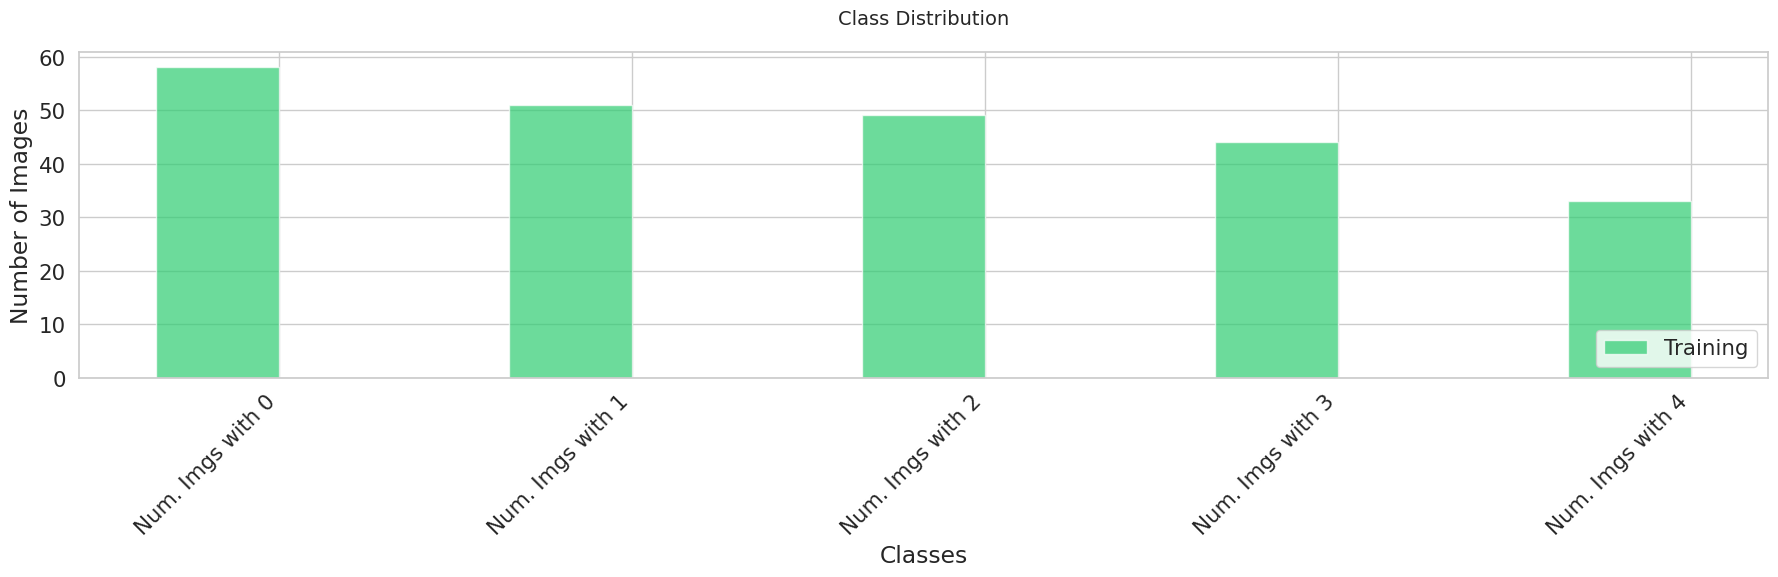

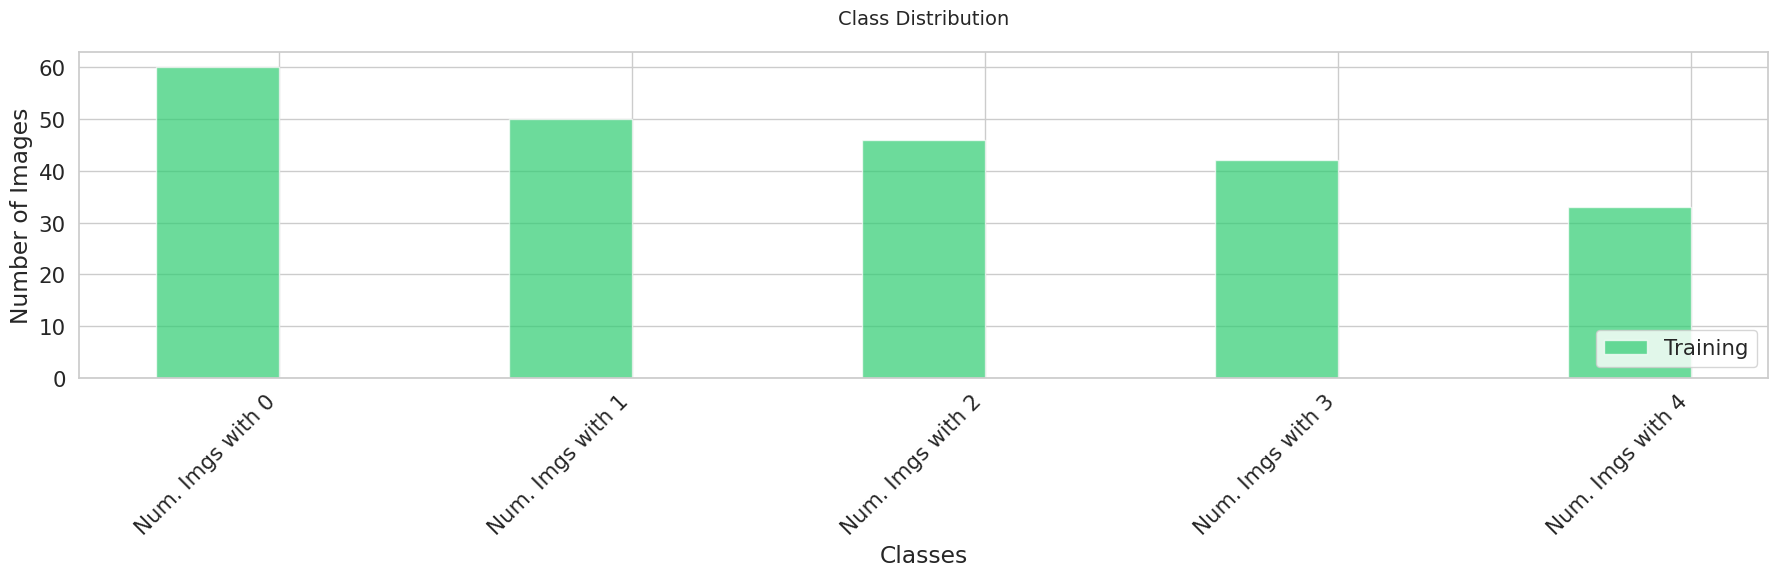

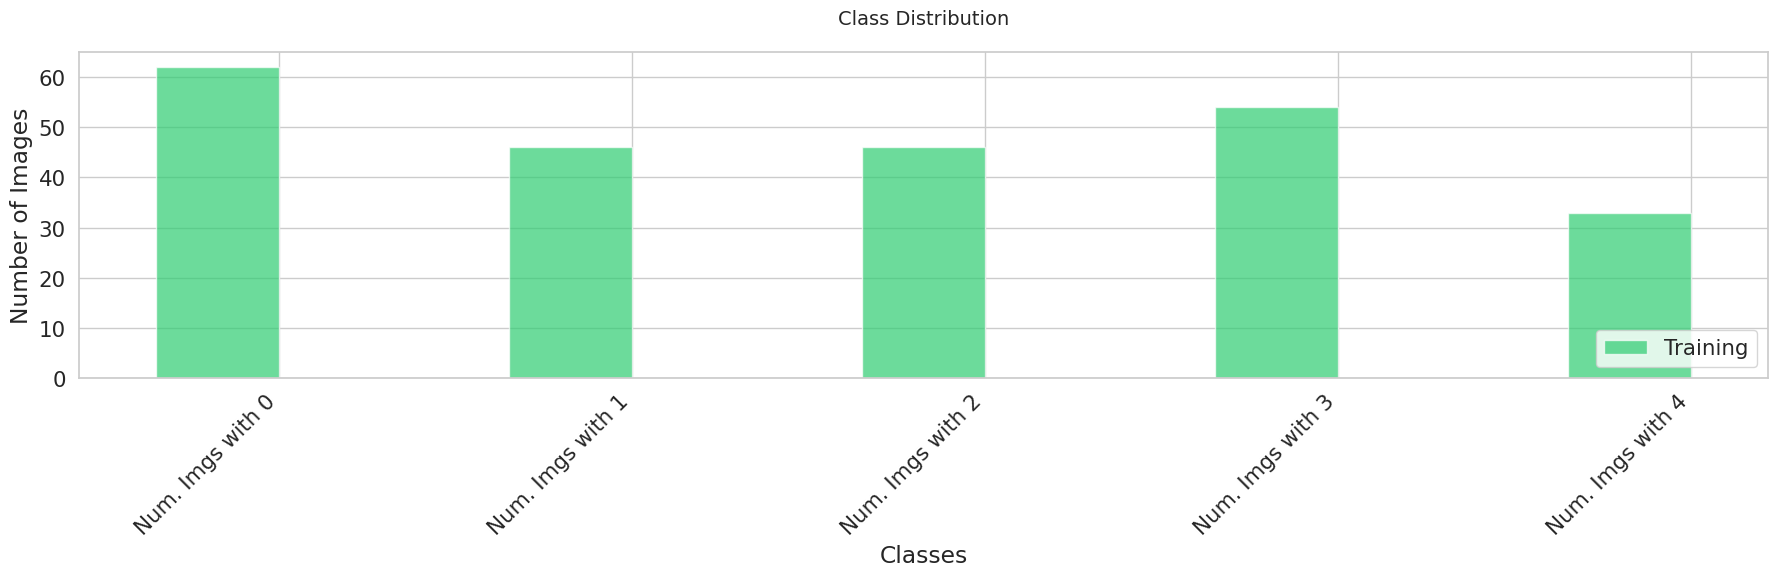

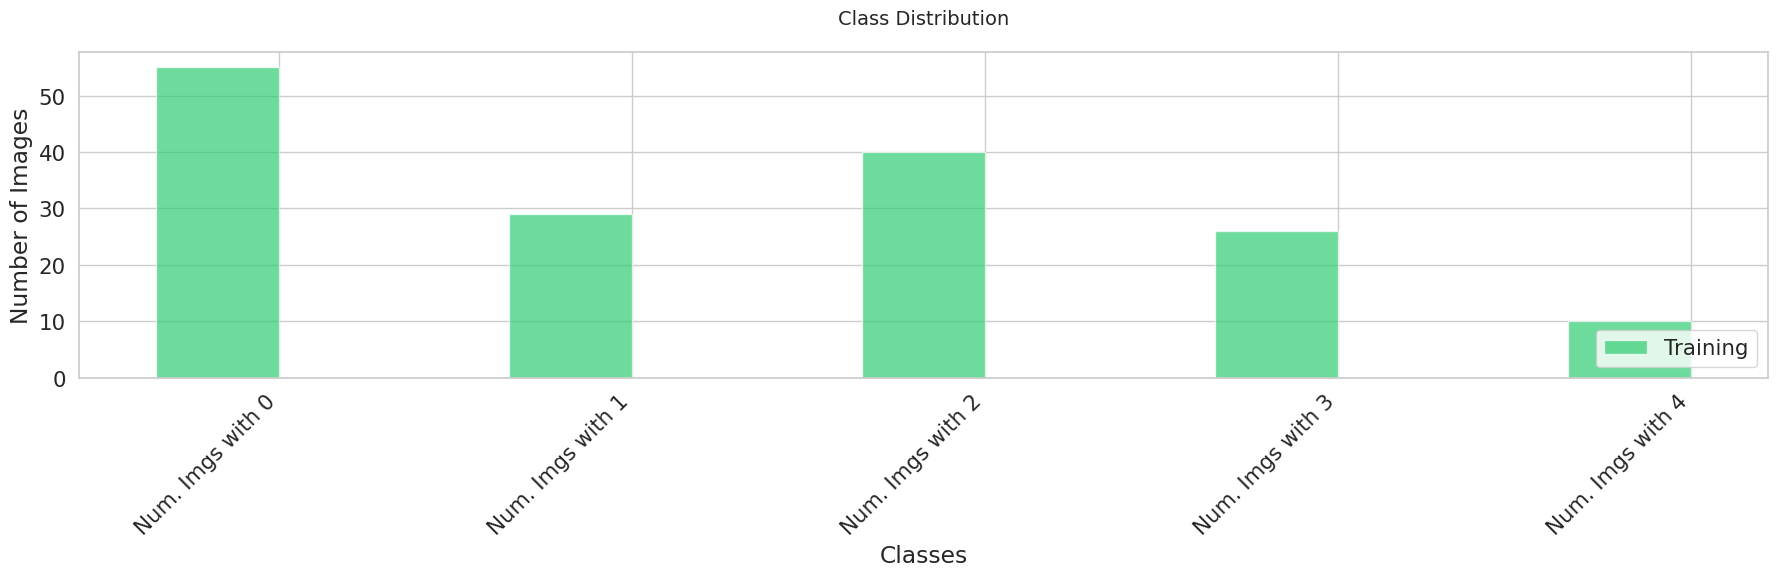

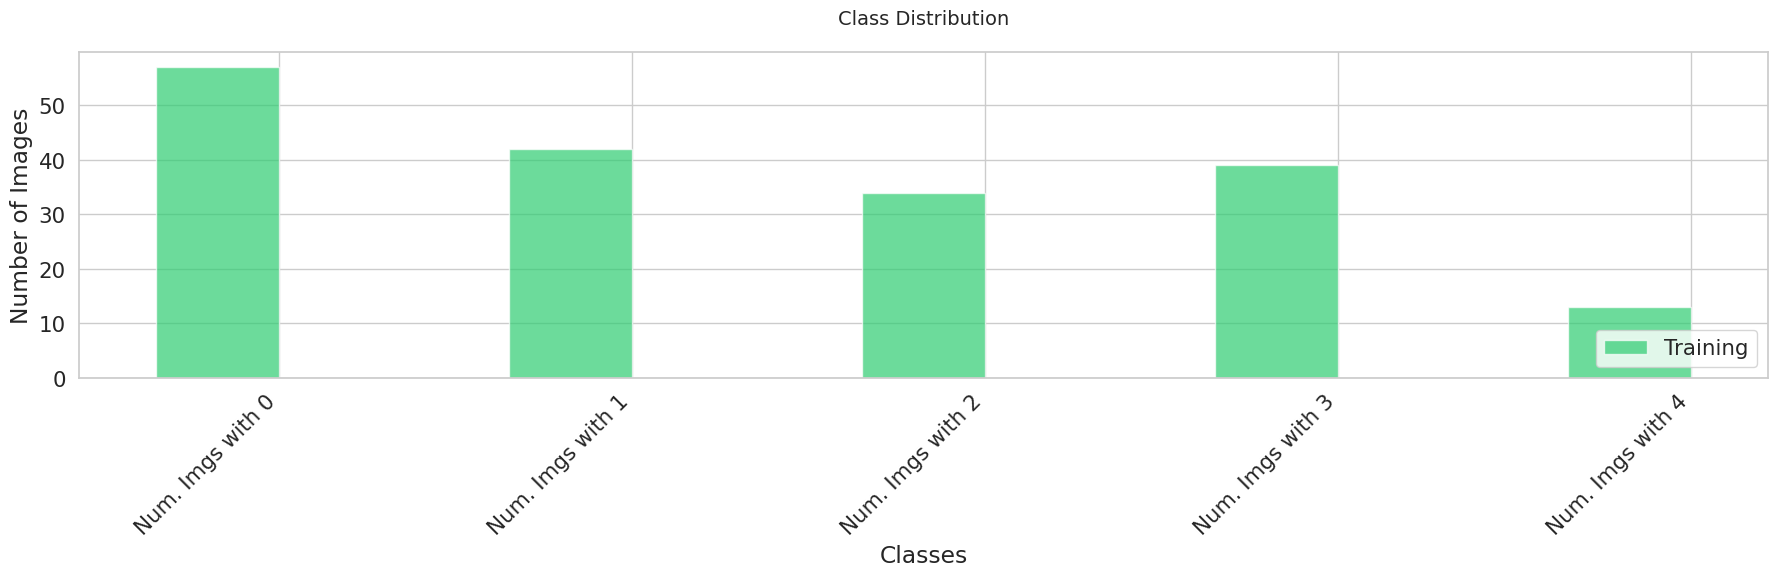

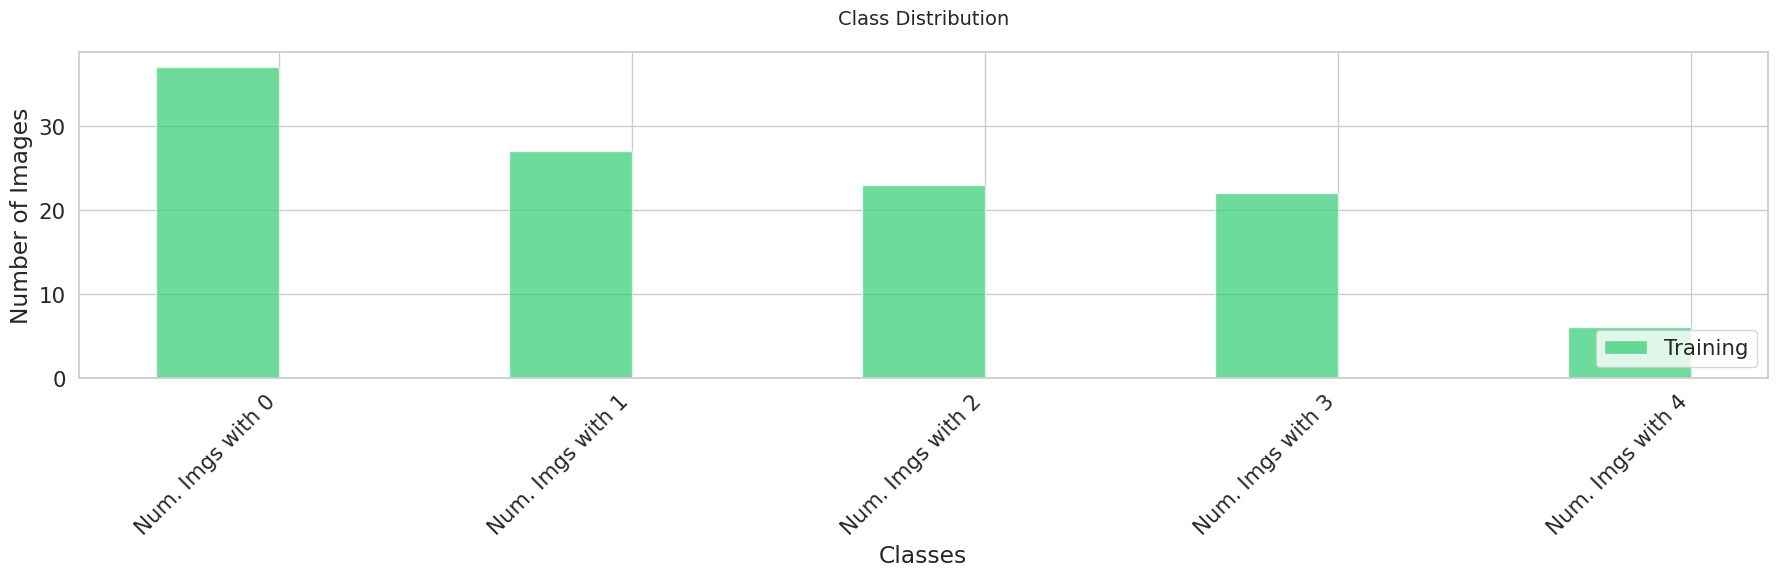

In [18]:
count = 0
for i in val_dataset_balanced:
  dll.plotClassDistribution(countSamplesInDatasetCreation(i[1].numpy()), classTitles)
  count += 1
  if count == 10:
    break